# Packages

In [1]:
from collections import defaultdict, deque

import ale_py
import gymnasium as gym
import json
import matplotlib.pyplot as plt
import numpy as np
import random
import time
import torch
import torch.nn as nn
import torch.optim as optim

gym.register_envs(ale_py)

# 1. Introduction and Game Description

In [2]:
env_exporation = gym.make('ALE/BasicMath-v5', obs_type="ram")

print("Observation space: ",env_exporation.observation_space)
print("Action space: ",env_exporation.action_space)
print("Meaning of the 6 actions: ",env_exporation.unwrapped.get_action_meanings())

state, info = env_exporation.reset()
print("\nState size (RAM): ",len(state)," values (ranging from 0 to 255)")

Observation space:  Box(0, 255, (128,), uint8)
Action space:  Discrete(6)
Meaning of the 6 actions:  ['NOOP', 'FIRE', 'UP', 'RIGHT', 'LEFT', 'DOWN']

State size (RAM):  128  values (ranging from 0 to 255)


Test of a random action:

In [3]:
action = env_exporation.action_space.sample()
next_state, reward, terminated, truncated, info = env_exporation.step(action)

print("\nDefault reward received: ",reward)

env_exporation.close()


Default reward received:  0.0


# 2. Baseline evaluation

## 2.1. Q-Learning with basic game penalty

We first define the Agent for the basic (tabular) Q-Learning:

In [6]:
class TabularQLearningAgent:
    """
    Standard Tabular Q-Learning Agent.
    Uses a dictionary to store Q-values because the RAM state space is too large for a traditional numpy array (avoids MemoryError).
    """
    def __init__(self, action_size=6, lr=0.1, gamma=0.99, epsilon_start=1.0, epsilon_end=0.01, epsilon_decay=0.995):
        """
        Initializes the Tabular Q-Learning agent and its hyperparameters.
        """
        self.action_size = action_size        # Number of possible actions 
        self.lr = lr                          # Learning rate 
        self.gamma = gamma                    # Discount factor (importance of long-term future rewards)
        self.epsilon = epsilon_start          # Current exploration rate
        self.epsilon_end = epsilon_end        # Minimum exploration rate
        self.epsilon_decay = epsilon_decay    # Multiplier used to gradually reduce exploration after each episode
        
        self.q_table = defaultdict(lambda: np.zeros(self.action_size)) #array of 6 zeros as initial value
        
        #Trackers to count how many times each action is chosen 
        self.exploitation_counts = {i: 0 for i in range(action_size)}

    def act(self, state):
        """
        Selects an action based on the current state using the Epsilon-Greedy policy 
        """
        # Convert state array to a tuple so it can be used as a dictionary key
        state_tuple = tuple(state)
        
        if random.random() < self.epsilon: # Epsilon-greedy policy - exploration
            return random.randrange(self.action_size)
        
        self.exploitation_counts[action] += 1 #update the count

        return np.argmax(self.q_table[state_tuple]) #exploitation

    def step(self, state, action, reward, next_state, done):
        """
        Updates the Q-table based on the agent's experience.
        """
        state_tuple = tuple(state)
        next_state_tuple = tuple(next_state)
        
        # Bellman equation update:
        best_next_action = np.argmax(self.q_table[next_state_tuple])
        td_target = reward + (0 if done else self.gamma * self.q_table[next_state_tuple][best_next_action])
        td_error = td_target - self.q_table[state_tuple][action]
        
        self.q_table[state_tuple][action] += self.lr * td_error

    def update_epsilon(self):
        """
        Decays the epsilon value at the end of each episode to smoothly shift the agent's behavior from exploration to exploitation.
        """
        self.epsilon = max(self.epsilon_end, self.epsilon * self.epsilon_decay)

Test of the agent on the basic penalty of the game:

In [7]:
env_basic = gym.make('ALE/BasicMath-v5', obs_type="ram")
agent_basic = TabularQLearningAgent(action_size=6)

episodes = 500
rewards_basic = []

for e in range(episodes):
    #Initialisation of the parameters:
    state, _ = env_basic.reset()
    total_reward = 0
    done = False
    truncated = False
    
    while not done and not truncated:
        action = agent_basic.act(state)
        next_state, reward, done, truncated, _ = env_basic.step(action)
        
        agent_basic.step(state, action, reward, next_state, done)
        
        state = next_state
        total_reward += reward
        
    agent_basic.update_epsilon()
    rewards_basic.append(total_reward)
    
    if (e + 1) % 50 == 0:
        avg_reward = np.mean(rewards_basic[-50:])
        print(f"Episode {e+1}/{episodes} | Avg Reward: {avg_reward:.2f} | Unique states in Q-Table: {len(agent_basic.q_table)}")

env_basic.close()

Episode 50/500 | Avg Reward: 0.04 | Unique states in Q-Table: 35882
Episode 100/500 | Avg Reward: 0.10 | Unique states in Q-Table: 71879
Episode 150/500 | Avg Reward: 0.10 | Unique states in Q-Table: 108006
Episode 200/500 | Avg Reward: 0.04 | Unique states in Q-Table: 146546
Episode 250/500 | Avg Reward: 0.14 | Unique states in Q-Table: 186873
Episode 300/500 | Avg Reward: 0.14 | Unique states in Q-Table: 230164
Episode 350/500 | Avg Reward: 0.12 | Unique states in Q-Table: 276917
Episode 400/500 | Avg Reward: 0.14 | Unique states in Q-Table: 327259
Episode 450/500 | Avg Reward: 0.14 | Unique states in Q-Table: 384986
Episode 500/500 | Avg Reward: 0.04 | Unique states in Q-Table: 447925


Action distribution chosen BY THE Q-Table:

Action 0: 250925 times
Action 1: 12306 times
Action 2: 12643 times
Action 3: 12287 times
Action 4: 12447 times
Action 5: 12459 times


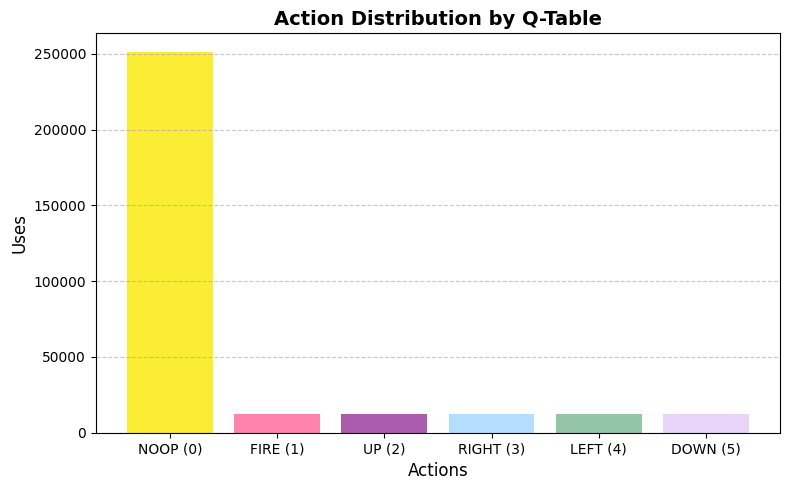

In [15]:
for act in range(agent_basic.action_size):
    print(f"Action {act}: {agent_basic.exploitation_counts[act]} times")

actions_labels = ['NOOP (0)', 'FIRE (1)', 'UP (2)', 'RIGHT (3)', 'LEFT (4)', 'DOWN (5)']
counts = [agent_basic.exploitation_counts[act] for act in range(agent_basic.action_size)]
colors = ['#FAE801', '#FF6699', '#983399', '#A3D5FF', '#79B791', '#E4CBF9']

plt.figure(figsize=(8, 5))
plt.bar(actions_labels, counts, color=colors, alpha=0.8)
plt.title("Action Distribution by Q-Table", fontsize=14, fontweight='bold')
plt.xlabel("Actions", fontsize=12)
plt.ylabel("Uses", fontsize=12)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

## 2.2. Penalty Wrapper on Time and Action

Definition of Time Penalty Wrapper:

In [2]:
class TimePenaltyWrapper(gym.RewardWrapper):
    """
    A custom wrapper that applies a small negative reward (penalty) at each step.
    This encourages the agent to solve the math problem as fast as possible rather than wandering around randomly.
    """

    def __init__(self, env, penalty=-0.01):
        super().__init__(env) #the rest of the environment remains the same 
        self.penalty = penalty #only changing the penalty

    def reward(self, reward):
        """
        This method is called automatically after every env.step().
        It intercepts the original reward and modifies it.
        """
        # If the original reward is 0 (the agent hasn't solved the problem yet), we give it a small penalty to simulate "losing time".
        if reward == 0.0:
            return self.penalty
        
        # If the agent actually scored a point (reward > 0), we keep the positive reward
        return reward

Test of the Time penalty wrapper:

In [12]:
base_env = gym.make('ALE/BasicMath-v5', obs_type="ram")
wrapped_env = TimePenaltyWrapper(base_env, penalty=-0.01)

state, info = wrapped_env.reset()
action = wrapped_env.action_space.sample()
next_state, custom_reward, terminated, truncated, info = wrapped_env.step(action)

print("Action taken: ",action)
print("Modified Reward received: ",custom_reward)

wrapped_env.close()

Action taken:  4
Modified Reward received:  -0.01


Definition of Action Penalty Wrapper:

In [3]:
class ActionPenaltyWrapper(gym.Wrapper):
    """
    This wrapper penalizes the agent if it uses the FIRE action (index 1) without scoring a point (meaning it submitted a wrong answer).
    This prevents it from randomly "spamming" the button.
    """
    def __init__(self, env, fire_penalty=-1.0): 
        super().__init__(env)
        self.fire_penalty = fire_penalty

    def step(self, action):
        # Execute the action normally in the environment
        obs, reward, terminated, truncated, info = self.env.step(action)
        
        # Modify the reward IF the action was FIRE (1) AND the agent got it wrong (reward == 0.0)
        if action == 1 and reward == 0.0:
            reward = self.fire_penalty
            
        return obs, reward, terminated, truncated, info

Test of the Action penalty wrapper on the 'FIRE' Action:

In [14]:
base_env_2 = gym.make('ALE/BasicMath-v5', obs_type="ram")
wrapped_env_2 = ActionPenaltyWrapper(base_env_2, fire_penalty=-1.0)

wrapped_env_2.reset()

forced_action = 1 # Force the agent to take action 1 (FIRE) to test the penalty
next_state, custom_reward, terminated, truncated, info = wrapped_env_2.step(forced_action)

print("Forced action: ",forced_action," (FIRE)")
print("Modified reward received: ",custom_reward)

wrapped_env_2.close()

Forced action:  1  (FIRE)
Modified reward received:  -1.0


## 2.3.  Q learning with new penalty policy

We now test our agent on the agent on the new penalty:

In [16]:
# Initialisation of the environment and the agent
base_env = gym.make('ALE/BasicMath-v5', obs_type="ram")
env_penalty = ActionPenaltyWrapper(base_env, fire_penalty=-0.01)
agent_penalty = TabularQLearningAgent(action_size=6)

episodes = 500
rewards_penalty = []

for e in range(episodes):
    state, _ = env_penalty.reset()
    total_reward = 0
    done = False
    truncated = False
    
    while not done and not truncated:
        action = agent_penalty.act(state)
        next_state, reward, done, truncated, _ = env_penalty.step(action)
        
        agent_penalty.step(state, action, reward, next_state, done)
        
        state = next_state
        total_reward += reward
        
    agent_penalty.update_epsilon()
    rewards_penalty.append(total_reward)
    
    if (e + 1) % 50 == 0:
        avg_reward = np.mean(rewards_penalty[-50:])
        print(f"Episode {e+1}/{episodes} | Avg Reward: {avg_reward:.2f} | Unique states in Q-Table: {len(agent_penalty.q_table)}")

env_penalty.close()

Episode 50/500 | Avg Reward: -1.04 | Unique states in Q-Table: 35500
Episode 100/500 | Avg Reward: -0.70 | Unique states in Q-Table: 71092
Episode 150/500 | Avg Reward: -0.66 | Unique states in Q-Table: 108137
Episode 200/500 | Avg Reward: -0.48 | Unique states in Q-Table: 146831
Episode 250/500 | Avg Reward: -0.37 | Unique states in Q-Table: 187964
Episode 300/500 | Avg Reward: -0.23 | Unique states in Q-Table: 231804
Episode 350/500 | Avg Reward: -0.25 | Unique states in Q-Table: 279486
Episode 400/500 | Avg Reward: -0.21 | Unique states in Q-Table: 330281
Episode 450/500 | Avg Reward: -0.12 | Unique states in Q-Table: 388119
Episode 500/500 | Avg Reward: -0.12 | Unique states in Q-Table: 450537


Action 0: 253127 times
Action 1: 12061 times
Action 2: 12548 times
Action 3: 12445 times
Action 4: 12687 times
Action 5: 12399 times


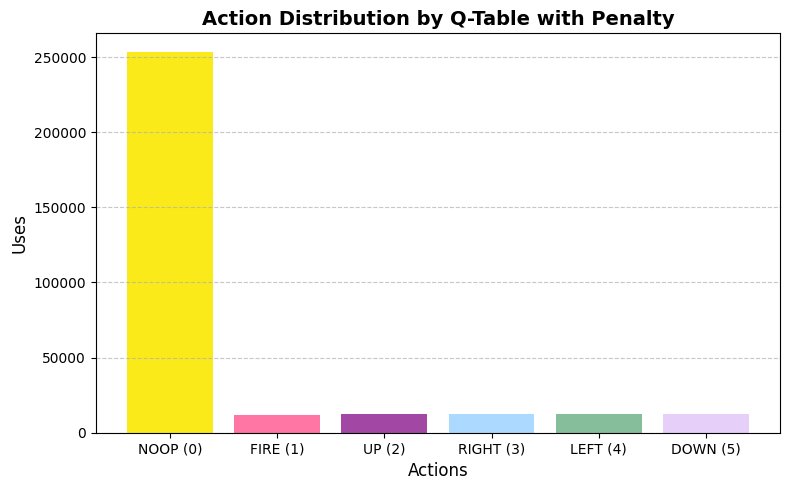

In [17]:
for act in range(agent_penalty.action_size):
    print(f"Action {act}: {agent_penalty.exploitation_counts[act]} times")


actions_labels = ['NOOP (0)', 'FIRE (1)', 'UP (2)', 'RIGHT (3)', 'LEFT (4)', 'DOWN (5)']
counts = [agent_penalty.exploitation_counts[act] for act in range(agent_penalty.action_size)]
colors = ['#FAE801', '#FF6699', '#983399', '#A3D5FF', '#79B791', '#E4CBF9']

plt.figure(figsize=(8, 5))
plt.bar(actions_labels, counts, color=colors, alpha=0.9)
plt.title("Action Distribution by Q-Table with Penalty", fontsize=14, fontweight='bold')
plt.xlabel("Actions", fontsize=12)
plt.ylabel("Uses", fontsize=12)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

# 3. Deep Reinforcement Learning: DQN Implementation

## 3.1. Network Architecture, Replay Buffer and DQN Agent

To solve this problem of the agent not playing, we transition to a Deep Q-Network (DQN) using PyTorch. The neural network will act as a function approximator to estimate Q-values directly from the continuous RAM state.

In [4]:
class QNetwork(nn.Module): #nn.Module basic class for NN in pytorch
    """
    Multi-Layer Perceptron (MLP) acting as our Q-function approximator.

    Input: 128 RAM variables. 
    Output: 6 Q-values (one for each action).
    """
    def __init__(self, state_size=128, action_size=6, hidden_size=128):
        """
        Initializes the fully connected layers of the neural network.
        We use 3 layers to provide enough capacity to abstract the RAM state.
        """
        super(QNetwork, self).__init__()
        self.fc1 = nn.Linear(state_size, hidden_size) # dense layers with y = Wx + b
        self.fc2 = nn.Linear(hidden_size, hidden_size)
        self.fc3 = nn.Linear(hidden_size, action_size)
        
    def forward(self, state):
        """
        Defines the forward pass of the network.
        
        """
        x = state.float() / 255.0 #Normalisation to avoid huge number 
        x = torch.relu(self.fc1(x))
        x = torch.relu(self.fc2(x))
        # No activation function on the last layer because Q-values can be negative, 
        return self.fc3(x) #layer 3 gives the prediction

class ReplayBuffer:
    """
    Stores agent experiences to break temporal correlation during training.

    - __init__: Initializes the memory buffer and sets its maximum capacity.
    - push: Stores a transition step containing (current state, chosen action, obtained reward, next state, end of episode boolean 'done').
    - sample: Randomly draws a mini-batch of past transitions from the buffer to train the neural network.
    - __len__: Returns the current number of stored transitions in the buffer (to make sure we do not excess its capacity).
    """
    def __init__(self, capacity=10000):
        """
        Initializes the memory buffer with a maximum capacity.
        Using a 'deque' ensures that oldest memories are automatically discarded when the buffer is full.
        'deque' serves as a FIFO waiting list with a limited capacity 
        """
        self.buffer = deque(maxlen=capacity)
    
    def push(self, state, action, reward, next_state, done):
        """
        Saves a single transition step into the memory buffer.
        """
        self.buffer.append((state, action, reward, next_state, done))
    
    def sample(self, batch_size):
        """
        Randomly samples a mini-batch of transitions for the network to learn from.
        This random sampling is crucial to prevent the network from overfitting to a specific sequence of actions (catastrophic forgetting).
        """
        batch = random.sample(self.buffer, batch_size)
        state, action, reward, next_state, done = map(np.stack, zip(*batch))
        return state, action, reward, next_state, done
    
    def __len__(self):
        """
        Returns the current number of transitions stored in the buffer.
        """
        return len(self.buffer)

In [28]:
class DQNAgent:
    """
    Deep Q-Network Agent integrating the neural network, memory, and learning logic.

    - __init__: Initializes hyperparameters, the optimizer, and TWO neural networks (Main and Target).
    - act: Selects an action using an Epsilon-Greedy policy (random exploration vs. network exploitation).
    - step: Saves the transition in the Replay Buffer and triggers the learning step if enough data is collected.
    - update: The core learning function computing the Bellman equation. Uses the Target Network to stabilize the loss calculation, then performs backpropagation on the Main Network.
    - update_epsilon: Gradually decays the exploration rate to favor exploitation over time.
    - update_target_network: Periodically copies the trained weights from the Main Network to the Target Network to prevent the 'moving target' problem.
    """
    def __init__(self, state_size=128, action_size=6, lr=1e-3, gamma=0.99, epsilon_start=1.0, epsilon_end=0.01, epsilon_decay=0.995):
        """
        Initializes the agent, the hyperparameters, the dual networks (Main and Target), and the Adam optimizer.
        """
        self.state_size = state_size          # Size of the input (128)
        self.action_size = action_size        # Number of possible actions (6)
        self.gamma = gamma                    # Discount factor (0.99): makes the agent care about long-term future rewards
        self.epsilon = epsilon_start          # Current exploration rate (starts at 1.0)
        self.epsilon_end = epsilon_end        # Minimum exploration rate (0.01)
        self.epsilon_decay = epsilon_decay    # Multiplier to gradually reduce epsilon after each episode 
        
        self.greedy_actions_count = {i: 0 for i in range(self.action_size)}
        self.random_actions_count = {i: 0 for i in range(self.action_size)}

        # Hardware selection: uses the Graphics Card (GPU) if one is detected, otherwise falls back to Processor (CPU)
        # I did the entire project only with CPU but I put this therefore people wwith GPU can use it
        self.device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
        
        # The Main Network: the one that actively plays the game and updates its weights at every training step
        self.q_network = QNetwork(state_size, action_size).to(self.device)
        
        # The Target Network: a frozen copy used only to calculate stable Bellman targets (prevents the "moving target" problem)
        self.target_network = QNetwork(state_size, action_size).to(self.device)
        
        # Immediately copy the random initial weights from the Main Network to the Target Network so they start identical
        self.target_network.load_state_dict(self.q_network.state_dict())
        
        # The Optimizer (Adam): the algorithm that mathematically adjusts the Main Network's weights using the Learning Rate (lr)
        self.optimizer = optim.Adam(self.q_network.parameters(), lr=lr)
        
        # The Memory: instantiates the Replay Buffer to store past transitions (solves catastrophic forgetting)
        self.memory = ReplayBuffer()
        
        # Batch Size: the number of past memories (64) we pull randomly from the buffer for each training step
        self.batch_size = 64

    def act(self, state):
        """
        Selects an action using an epsilon-greedy policy.
        With probability epsilon, it explores randomly (exploration). Otherwise, it asks the neural network to predict the best action (exploitation).
        """
        if random.random() < self.epsilon:
            self.random_actions_count[action] += 1
            return random.randrange(self.action_size)
        
        # Pythorch does not understand numpy so we transform the RAM into a tensor of float 
        # unsqueeze(0) converts the [128] into [1, 128] for [size of the batch, nb of variables] needed by Pytorch
        state_tensor = torch.FloatTensor(state).unsqueeze(0).to(self.device) 
        with torch.no_grad(): #security and optimisation for Pytorch to go fast and not store every step of the NN
            q_values = self.q_network(state_tensor)

        self.greedy_actions_count[action] += 1
        return q_values.argmax().item()

    def step(self, state, action, reward, next_state, done):
        """
        Stores the current transition in the Replay Buffer.
        If the buffer has enough samples, it triggers the neural network training step.
        """
        self.memory.push(state, action, reward, next_state, done)
        if len(self.memory) > self.batch_size:
            self.update()

    def update(self):
        """
        The core learning function.
        1. Samples a batch from memory.
        2. Computes the current Q-values.
        3. Computes the Target Q-values using the Bellman equation and the frozen Target Network.
        4. Calculates the Mean Squared Error (MSE) loss and performs backpropagation.
        """
        states, actions, rewards, next_states, dones = self.memory.sample(self.batch_size)
        
        states = torch.FloatTensor(states).to(self.device)
        actions = torch.LongTensor(actions).unsqueeze(1).to(self.device) 
        # unsqueeze(1) transforms [64] into [64, 1], that is we had for the actions [a1, a2, ...] a list now we have a column vector [[a1], [a2], ...]
        rewards = torch.FloatTensor(rewards).unsqueeze(1).to(self.device)
        next_states = torch.FloatTensor(next_states).to(self.device)
        dones = torch.FloatTensor(dones).unsqueeze(1).to(self.device)
        
        current_q_values = self.q_network(states).gather(1, actions)
        # self.q_network(states) returns a tensor of size [64, 6]
        # gather(1, actions) uses the action tensor as indices to know which Q-Value it needs to return and therefore select for right Q-value for each of the 64 batch
        
        with torch.no_grad(): #security and optimisation
            max_next_q_values = self.target_network(next_states).max(1, keepdim=True)[0]
            # max(1) returns the maxima value of each line (needed by Bellman eq)
            # keepdim=True is for Pytorch to not squeeze [64, 1] into [64] (needed for the following operation to work as reward is of size [64, 1])
            target_q_values = rewards + (self.gamma * max_next_q_values * (1 - dones))
        
        # Backpropagation:
        loss = nn.MSELoss()(current_q_values, target_q_values)
        self.optimizer.zero_grad() #Reset the gradients of all optimized torch.Tensor s.
        loss.backward()
        self.optimizer.step()

    def update_epsilon(self):
        """
        Gradually reduces the exploration rate at the end of an episode.
        """
        self.epsilon = max(self.epsilon_end, self.epsilon_decay * self.epsilon)

    def update_target_network(self):
        """
        Copies the weights from the actively training network to the frozen target network.
        This provides a stable target for the Bellman equation.
        """
        self.target_network.load_state_dict(self.q_network.state_dict())

## 3.2. Computational Optimization: Frame Skipping

In [29]:
class SkipFrameWrapper(gym.Wrapper):
    """
    Wrapper to apply Frame Skipping (Action Repeat).
    Instead of making a decision every single frame (60 times per second),the agent chooses an action and repeats it for 'skip' frames.
    
    Idea : As consecutive frames are nearly identical, running the Deep Q-Network on every single frame is computationally expensive and doesn't provide new information. 
    Skipping 4 frames drastically speeds up training and forces the agent to commit to an action."
    """
    def __init__(self, env, skip=4):
        super().__init__(env)
        self.skip = skip

    def step(self, action):
        total_reward = 0.0
        done = False
        truncated = False
        
        # Repeat the action 'skip' times
        for _ in range(self.skip):
            obs, reward, done, truncated, info = self.env.step(action)
            total_reward += reward
            if done or truncated:
                break
                
        return obs, total_reward, done, truncated, info

In [30]:

episodes = 150 
all_rewards = {}
all_times = {}
agents = {}


for s_val in [1, 4]:
    
    base_env = gym.make('ALE/BasicMath-v5', obs_type="ram")
    env = ActionPenaltyWrapper(base_env, fire_penalty=-1.0)
    env = SkipFrameWrapper(env, skip=s_val)
    
    agent = DQNAgent(state_size=128, action_size=6)
    rewards_history = []
    start_t = time.time()
    
    print("Training DQN with ", s_val, " step:")
    
    for e in range(1, episodes + 1):
        state, _ = env.reset()
        total_reward = 0
        done, truncated = False, False
        
        while not done and not truncated:
            action = agent.act(state)
            next_state, reward, done, truncated, _ = env.step(action)
            agent.step(state, action, reward, next_state, done)
            state = next_state
            total_reward += reward
            
        agent.update_epsilon()
        rewards_history.append(total_reward)
        
        if e % 10 == 0:
            agent.update_target_network()
            avg_rew = np.mean(rewards_history[-10:])
            elapsed = (time.time() - start_t) / 60
            print(f"Ep: {e}/{episodes} | Eps: {agent.epsilon:.3f} | Avg Reward: {avg_rew:.2f} | Time: {elapsed:.1f} min")
            
    # Storing results
    all_rewards[f"skip{s_val}"] = rewards_history
    all_times[f"skip{s_val}"] = (time.time() - start_t) / 60
    agents[f"agent_skip{s_val}"] = agent
    env.close()

agent_skip1 = agents["agent_skip1"]
agent_skip4 = agents["agent_skip4"]


Training DQN with  1  step:
Ep: 10/150 | Eps: 0.951 | Avg Reward: -114.80 | Time: 0.6 min
Ep: 20/150 | Eps: 0.905 | Avg Reward: -108.90 | Time: 1.2 min
Ep: 30/150 | Eps: 0.860 | Avg Reward: -109.10 | Time: 1.9 min
Ep: 40/150 | Eps: 0.818 | Avg Reward: -104.70 | Time: 2.6 min
Ep: 50/150 | Eps: 0.778 | Avg Reward: -96.00 | Time: 3.3 min
Ep: 60/150 | Eps: 0.740 | Avg Reward: -94.40 | Time: 4.1 min
Ep: 70/150 | Eps: 0.704 | Avg Reward: -87.80 | Time: 5.1 min
Ep: 80/150 | Eps: 0.670 | Avg Reward: -82.30 | Time: 6.0 min
Ep: 90/150 | Eps: 0.637 | Avg Reward: -76.30 | Time: 7.1 min
Ep: 100/150 | Eps: 0.606 | Avg Reward: -79.80 | Time: 8.3 min
Ep: 110/150 | Eps: 0.576 | Avg Reward: -69.80 | Time: 9.5 min
Ep: 120/150 | Eps: 0.548 | Avg Reward: -65.60 | Time: 10.7 min
Ep: 130/150 | Eps: 0.521 | Avg Reward: -67.70 | Time: 12.0 min
Ep: 140/150 | Eps: 0.496 | Avg Reward: -67.60 | Time: 13.4 min
Ep: 150/150 | Eps: 0.471 | Avg Reward: -61.30 | Time: 14.7 min
Training DQN with  4  step:
Ep: 10/150 | Ep

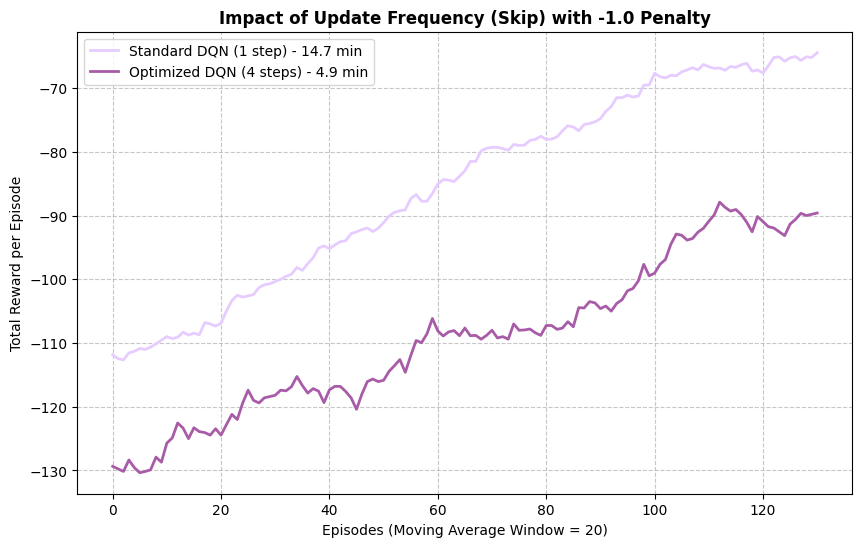

In [31]:
plt.figure(figsize=(10, 6))
ma_1 = np.convolve(all_rewards["skip1"], np.ones(20)/20, mode='valid')
ma_4 = np.convolve(all_rewards["skip4"], np.ones(20)/20, mode='valid')

plt.plot(ma_1, label=f"Standard DQN (1 step) - {all_times['skip1']:.1f} min", color='#E6CCFF', linewidth=2)
plt.plot(ma_4, label=f"Optimized DQN (4 steps) - {all_times['skip4']:.1f} min", color='#A85CA8', linestyle='--',  linewidth=2)

plt.title("Impact of Update Frequency (Skip) with -1.0 Penalty", fontsize=12, fontweight='bold')
plt.xlabel("Episodes (Moving Average Window = 20)")
plt.ylabel("Total Reward per Episode")
plt.legend()
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()

In [34]:
print("\nResult of Standard DQN (1 step):")
for a, count in agents["agent_skip1"].greedy_actions_count.items():
    print(f"Action {a} : {count} fois")

print("\nOptimized DQN (4 steps):")
for a, count in agents["agent_skip4"].greedy_actions_count.items():
    print(f"Action {a} : {count} fois")


Result of Standard DQN (1 step):
Action 0 : 5698 fois
Action 1 : 3479 fois
Action 2 : 5855 fois
Action 3 : 5876 fois
Action 4 : 5930 fois
Action 5 : 6308 fois

Optimized DQN (4 steps):
Action 0 : 2089 fois
Action 1 : 1172 fois
Action 2 : 1921 fois
Action 3 : 1835 fois
Action 4 : 1858 fois
Action 5 : 2063 fois


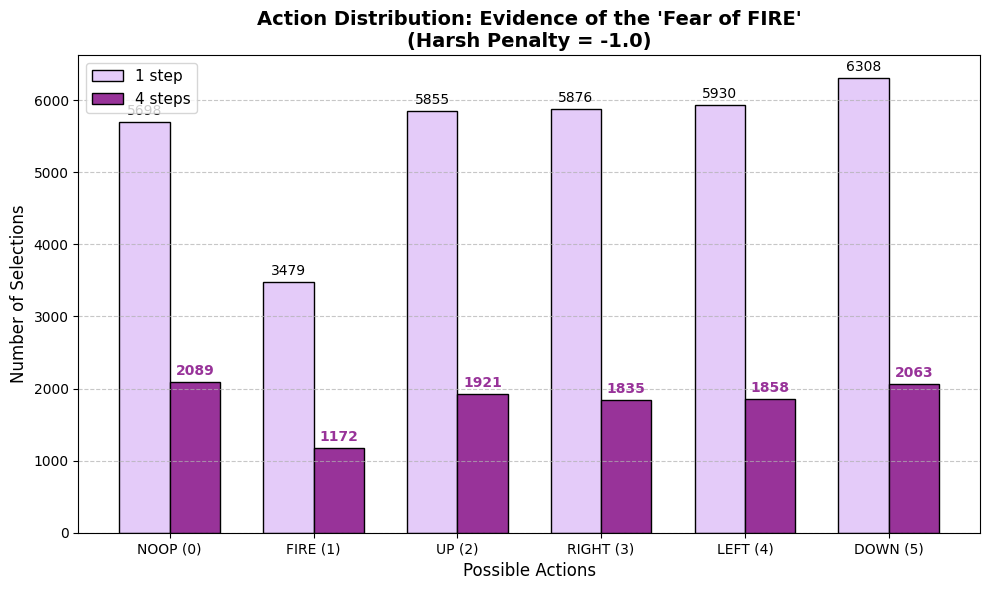

In [54]:
actions = np.arange(6)
actions_labels = ['NOOP (0)', 'FIRE (1)', 'UP (2)', 'RIGHT (3)', 'LEFT (4)', 'DOWN (5)']
exploitation_counts_1 = [5698, 3479, 5855, 5876, 5930, 6308]
exploitation_counts_4 = [2089, 1172, 1921, 1835, 1858, 2063]

width = 0.35  # Bar width
fig, ax = plt.subplots(figsize=(10, 6))

bars1 = ax.bar(actions - width/2, exploitation_counts_1, width, label='1 step', color='#E4CBF9', edgecolor='black')
bars2 = ax.bar(actions + width/2, exploitation_counts_4, width, label='4 steps', color='#983399', edgecolor='black')

ax.set_xlabel('Possible Actions', fontsize=12)
ax.set_ylabel('Number of Selections', fontsize=12)
ax.set_title("Action Distribution: Evidence of the 'Fear of FIRE'\n(Harsh Penalty = -1.0)", fontsize=14, fontweight='bold')
ax.set_xticks(actions)
ax.set_xticklabels(actions_labels)
ax.legend(fontsize=11)
ax.grid(axis='y', linestyle='--', alpha=0.7)


ax.bar_label(bars1, padding=3, fontsize=10)
ax.bar_label(bars2, padding=3, fontsize=10, color='#983399', fontweight='bold')

plt.tight_layout()
plt.show()

# 4. Reward Shaping and the "Fear of FIRE" Dilemma

## 4.1. Comparison of rewards

Now that our Deep Q-Network is computationally optimized with Frame Skipping, we evaluate its ability to learn from the environment's native sparse rewards.  We will test different Reward Shaping strategies to help the agent discover the goal.

Training Baseline:
Ep: 10/150 | Eps: 0.951 | Avg Reward: 0.00 | Time: 0.3 min
Ep: 20/150 | Eps: 0.905 | Avg Reward: 0.00 | Time: 0.6 min
Ep: 30/150 | Eps: 0.860 | Avg Reward: 0.00 | Time: 0.9 min
Ep: 40/150 | Eps: 0.818 | Avg Reward: 0.30 | Time: 1.3 min
Ep: 50/150 | Eps: 0.778 | Avg Reward: 0.00 | Time: 1.9 min
Ep: 60/150 | Eps: 0.740 | Avg Reward: 0.20 | Time: 2.8 min
Ep: 70/150 | Eps: 0.704 | Avg Reward: 0.10 | Time: 3.5 min
Ep: 80/150 | Eps: 0.670 | Avg Reward: 0.20 | Time: 3.8 min
Ep: 90/150 | Eps: 0.637 | Avg Reward: 0.30 | Time: 4.1 min
Ep: 100/150 | Eps: 0.606 | Avg Reward: 0.10 | Time: 4.4 min
Ep: 110/150 | Eps: 0.576 | Avg Reward: 0.10 | Time: 4.7 min
Ep: 120/150 | Eps: 0.548 | Avg Reward: 0.40 | Time: 5.0 min
Ep: 130/150 | Eps: 0.521 | Avg Reward: 0.40 | Time: 5.3 min
Ep: 140/150 | Eps: 0.496 | Avg Reward: 0.30 | Time: 5.6 min
Ep: 150/150 | Eps: 0.471 | Avg Reward: 0.30 | Time: 5.9 min
Training Time Penalty (-0.01):
Ep: 10/150 | Eps: 0.951 | Avg Reward: -9.03 | Time: 0.3 min

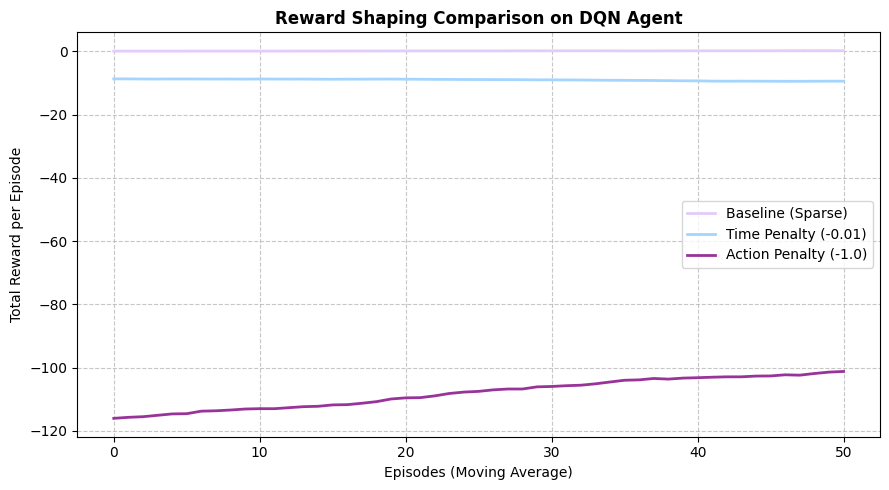

In [57]:
def train_agent_for_comparison(wrapper_class=None, wrapper_kwargs=None, episodes=150):
    """
    Automates the training process for different agent configurations to ensure fair comparison.

    This function streamlines the evaluation of various Reward Shaping strategies or Hyperparameters (like Frame Skipping). It performs the following steps:
    - Wraps the base Gymnasium environment with the specified reward and skip wrappers.
    - Initializes a fresh DQNAgent and trains it for a fixed number of episodes.
    - Implements the epsilon-decay and target network update logic.
    - Collects total rewards per episode to allow for later performance plotting.

    Args:
        env_class: The base environment (usually gym.make('ALE/BasicMath-v5')).
        wrapper_class: The reward shaping wrapper to apply (e.g., ActionPenaltyWrapper).
        wrapper_kwargs: Dictionary of arguments for the wrapper (e.g., {'penalty': -1.0}).
        episodes: Total number of training episodes (default: 150).

    Returns:
        tuple: (rewards_list, trained_agent) 
               - rewards_list: List of scores for each episode.
               - trained_agent: The DQNAgent object with learned weights.
    """
    
    base_env = gym.make('ALE/BasicMath-v5', obs_type="ram")
    if wrapper_class:
        base_env = wrapper_class(base_env, **wrapper_kwargs)
    env = SkipFrameWrapper(base_env, skip=4)
    
    agent = DQNAgent(state_size=128, action_size=6)
    rewards_history = []
    start_t = time.time()
    
    for e in range(1, episodes +1):
        state, _ = env.reset()
        total_reward = 0
        done, truncated = False, False

        while not done and not truncated:
            action = agent.act(state)
            next_state, reward, done, truncated, _ = env.step(action)
            agent.step(state, action, reward, next_state, done)
            state = next_state
            total_reward += reward
        agent.update_epsilon()

        rewards_history.append(total_reward)

        if e % 10 == 0:
            agent.update_target_network()
            avg_rew = np.mean(rewards_history[-10:])
            elapsed = (time.time() - start_t) / 60
            print(f"Ep: {e}/{episodes} | Eps: {agent.epsilon:.3f} | Avg Reward: {avg_rew:.2f} | Time: {elapsed:.1f} min")
        
    env.close()
    
    return rewards_history, agent

print("Training Baseline:")
result_baseline = train_agent_for_comparison(None)

print("Training Time Penalty (-0.01):")
result_time = train_agent_for_comparison(TimePenaltyWrapper, {'penalty': -0.01})

print("Training Action Penalty (-1.0):")
result_action = train_agent_for_comparison(ActionPenaltyWrapper, {'fire_penalty': -1.0})

def moving_average(data, window_size=100):
    """
    Computes the moving average of a 1D array to smooth out high-variance training data.

    Args:
        data (list or numpy.ndarray): The raw sequence of rewards per episode.
        window_size (int): The number of episodes to average over.

    Returns:
        numpy.ndarray: The smoothed array of rewards. The length of the returned 
                       array is (len(data) - window_size + 1) due to 'valid' mode.
    """
    return np.convolve(data, np.ones(window_size)/window_size, mode='valid')

plt.figure(figsize=(9, 5))
plt.plot(moving_average(result_baseline[0]), label="Baseline (Sparse)", color='#E4CBF9', linewidth=2)
plt.plot(moving_average(result_time[0]), label="Time Penalty (-0.01)", color='#A3D5FF', linewidth=2)
plt.plot(moving_average(result_action[0]), label="Action Penalty (-1.0)", color='#983399', linewidth=2)

plt.title("Reward Shaping Comparison on DQN Agent", fontsize=12, fontweight='bold')
plt.xlabel("Episodes (Moving Average)", fontsize=10)
plt.ylabel("Total Reward per Episode", fontsize=10)
plt.legend()
plt.grid(True, linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

## 4.2 The "Fear of FIRE" Phenomenon

Graph that show that it does not learn to fire as it is afraid to loose as points:

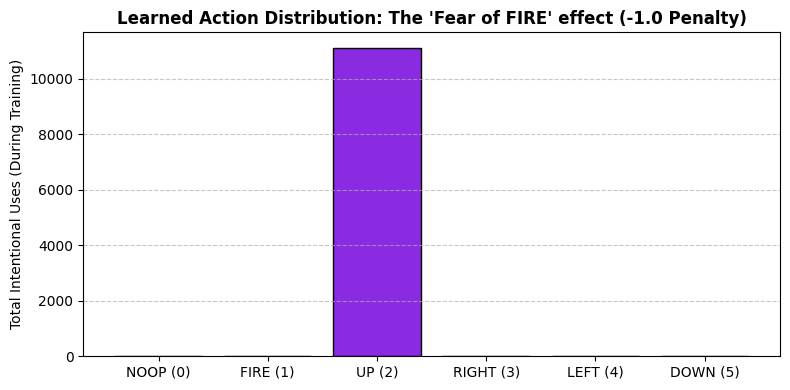

In [58]:
agent = result_action[1]
counts = [agent.greedy_actions_count[i] for i in range(6)]
actions_labels = ['NOOP (0)', 'FIRE (1)', 'UP (2)', 'RIGHT (3)', 'LEFT (4)', 'DOWN (5)']

plt.figure(figsize=(8, 4))
bars = plt.bar(actions_labels, counts, color=['#FFD700', '#FF69B4', '#8A2BE2', '#87CEFA', '#8FBC8F', '#E6E6FA'], edgecolor='black')
plt.title("Learned Action Distribution: The 'Fear of FIRE' effect (-1.0 Penalty)", fontsize=12, fontweight='bold')
plt.ylabel("Total Intentional Uses (During Training)", fontsize=10)

plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()


## 4.3 Refining the Penalty - Tuned Reward Shaping

Test of four different penalties between -1.0 and 0.0:


Training DQN with FIRE penalty = -1.0:
Ep: 50/150 | Eps: 0.778 | Avg Reward: -126.02 | Time: 3.3 min
Ep: 100/150 | Eps: 0.606 | Avg Reward: -112.86 | Time: 4.7 min
Ep: 150/150 | Eps: 0.471 | Avg Reward: -91.06 | Time: 7.1 min
Done in 7.2 minutes. Average Reward (last 50): -91.06

Training DQN with FIRE penalty = -0.5:
Ep: 50/150 | Eps: 0.778 | Avg Reward: -63.01 | Time: 2.5 min
Ep: 100/150 | Eps: 0.606 | Avg Reward: -54.17 | Time: 4.1 min
Ep: 150/150 | Eps: 0.471 | Avg Reward: -45.51 | Time: 7.0 min
Done in 7.0 minutes. Average Reward (last 50): -45.51

Training DQN with FIRE penalty = -0.1:
Ep: 50/150 | Eps: 0.778 | Avg Reward: -13.05 | Time: 6.0 min
Ep: 100/150 | Eps: 0.606 | Avg Reward: -10.72 | Time: 8.6 min
Ep: 150/150 | Eps: 0.471 | Avg Reward: -9.55 | Time: 10.8 min
Done in 10.8 minutes. Average Reward (last 50): -9.55

Training DQN with FIRE penalty = 0.0:
Ep: 50/150 | Eps: 0.778 | Avg Reward: 0.10 | Time: 2.8 min
Ep: 100/150 | Eps: 0.606 | Avg Reward: 0.14 | Time: 4.8 min
Ep:

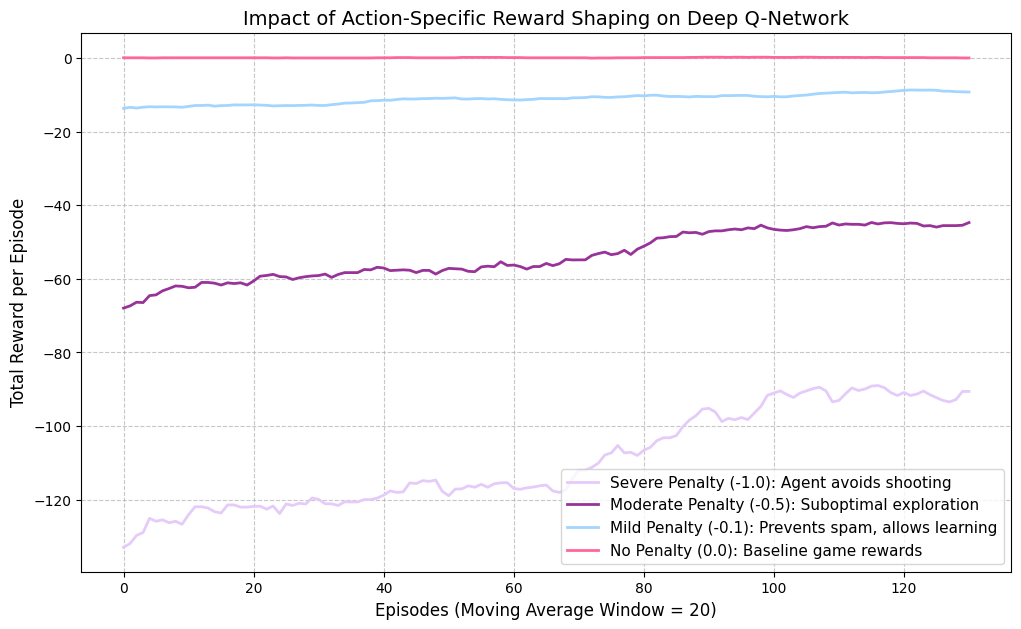

In [61]:
PENALTIES = [-1.0, -0.5, -0.1, 0.0]

experiment_results = {}

for penalty in PENALTIES:
    print(f"\nTraining DQN with FIRE penalty = {penalty}:")
    
    env = ActionPenaltyWrapper(gym.make('ALE/BasicMath-v5', obs_type="ram"), fire_penalty=penalty)
    env = SkipFrameWrapper(env, skip=4)

    agent = DQNAgent(state_size=128, action_size=6)
    rewards_history = []
    start_time = time.time()
    
    for e in range(150):
        state, _ = env.reset()
        total_reward = 0
        done = False
        truncated = False
        
        while not done and not truncated:
            action = agent.act(state)
            next_state, reward, done, truncated, _ = env.step(action)
            agent.step(state, action, reward, next_state, done)
            state = next_state
            total_reward += reward
            
        agent.update_epsilon()
        rewards_history.append(total_reward)

        if (e + 1) % 50 == 0:
            agent.update_target_network()
            avg_rew = np.mean(rewards_history[-50:])
            elapsed = (time.time() - start_time) / 60
            print(f"Ep: {e + 1}/{episodes} | Eps: {agent.epsilon:.3f} | Avg Reward: {avg_rew:.2f} | Time: {elapsed:.1f} min")
        
    training_time = (time.time() - start_time) / 60
    print(f"Done in {training_time:.1f} minutes. Average Reward (last 50): {np.mean(rewards_history[-50:]):.2f}")
    
    
    experiment_results[penalty] = rewards_history
    
    env.close()

plt.figure(figsize=(12, 7))
window = 20

colors = {-1.0: '#E4CBF9', -0.5:'#983399', -0.1: '#A3D5FF', 0.0: '#FF6699'}
labels = {
    -1.0: 'Severe Penalty (-1.0): Agent avoids shooting',
    -0.5: 'Moderate Penalty (-0.5): Suboptimal exploration',
    -0.1: 'Mild Penalty (-0.1): Prevents spam, allows learning',
     0.0: 'No Penalty (0.0): Baseline game rewards'
}

for penalty, rewards in experiment_results.items():
    plt.plot(moving_average(rewards, window), 
             label=labels[penalty], 
             color=colors[penalty], 
             linewidth=2)

plt.title('Impact of Action-Specific Reward Shaping on Deep Q-Network', fontsize=14)
plt.xlabel(f'Episodes (Moving Average Window = {window})', fontsize=12)
plt.ylabel('Total Reward per Episode', fontsize=12)
plt.legend(fontsize=11)
plt.grid(True, linestyle='--', alpha=0.7)

plt.show()

# 5. Comparative Analysis: Deep Q-Network vs. Deep SARSA vs. Deep Monte Carlo

## 5.1. Implementation of the three methods

To simplify the code we implement a new version of DQN Agent witth the update every 4 steps.

In [8]:
class DQNAgent:
    """
    Deep Q-Network Agent integrating the neural network, memory, and learning logic.
    New version, for more details see 3.1.

    - __init__: Initializes hyperparameters, the optimizer, and TWO neural networks (Main and Target).
    - act: Selects an action using an Epsilon-Greedy policy (random exploration vs. network exploitation).
    - step: Saves the transition in the Replay Buffer and triggers the learning step if enough data is collected.
    - update: The core learning function computing the Bellman equation. Uses the Target Network to stabilize the loss calculation, then performs backpropagation on the Main Network.
    - update_epsilon: Gradually decays the exploration rate to favor exploitation over time.
    - update_target_network: Periodically copies the trained weights from the Main Network to the Target Network to prevent the 'moving target' problem.
    """
    def __init__(self, state_size=128, action_size=6, lr=1e-3, gamma=0.99, epsilon_start=1.0, epsilon_end=0.01, epsilon_decay=0.995):
        """
        New version where we update every 4 steps to simplify the code
        """
        self.state_size = state_size
        self.action_size = action_size
        self.gamma = gamma
        self.epsilon = epsilon_start
        self.epsilon_end = epsilon_end
        self.epsilon_decay = epsilon_decay
        
        self.update_every = 4 
        self.t_step = 0 

        self.greedy_actions_count = {i: 0 for i in range(self.action_size)}
        self.random_actions_count = {i: 0 for i in range(self.action_size)}

        # Details of the role of each line in section 3.1.
        self.device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
        self.q_network = QNetwork(state_size, action_size).to(self.device)
        self.target_network = QNetwork(state_size, action_size).to(self.device)
        self.target_network.load_state_dict(self.q_network.state_dict())
        
        self.optimizer = optim.Adam(self.q_network.parameters(), lr=lr)
        self.memory = ReplayBuffer()
        self.batch_size = 64

    def act(self, state):
        if random.random() < self.epsilon:
            action = random.randrange(self.action_size)
            self.random_actions_count[action] += 1
            return action 
        state_tensor = torch.FloatTensor(state).unsqueeze(0).to(self.device) 
        with torch.no_grad():
            q_values = self.q_network(state_tensor)
        action = q_values.argmax().item()
        self.greedy_actions_count[action] += 1
        return action 

    def step(self, state, action, reward, next_state, done):
        self.memory.push(state, action, reward, next_state, done)
        
        # Added in order to adapt to the new step update
        self.t_step = (self.t_step + 1) % self.update_every
        if self.t_step == 0:
            if len(self.memory) > self.batch_size:
                self.update()

    def update(self):
        states, actions, rewards, next_states, dones = self.memory.sample(self.batch_size)
        states = torch.FloatTensor(states).to(self.device)
        actions = torch.LongTensor(actions).unsqueeze(1).to(self.device)
        rewards = torch.FloatTensor(rewards).unsqueeze(1).to(self.device)
        next_states = torch.FloatTensor(next_states).to(self.device)
        dones = torch.FloatTensor(dones).unsqueeze(1).to(self.device)
        
        current_q_values = self.q_network(states).gather(1, actions)
        
        with torch.no_grad():
            max_next_q_values = self.target_network(next_states).max(1, keepdim=True)[0]
            target_q_values = rewards + (self.gamma * max_next_q_values * (1 - dones))
            
        loss = nn.MSELoss()(current_q_values, target_q_values)
        self.optimizer.zero_grad()
        loss.backward() 
        self.optimizer.step()

    def update_epsilon(self):
        self.epsilon = max(self.epsilon_end, self.epsilon_decay * self.epsilon)

    def update_target_network(self):
        self.target_network.load_state_dict(self.q_network.state_dict())



class DeepSarsaAgent(DQNAgent):
    """
    Deep SARSA Agent inheriting from our DQNAgent.
    The neural network architecture and memory buffer remain identical.
    Only the target calculation in the update() method changes to reflect the On-Policy nature of SARSA.
    """
    def __init__(self, state_size=128, action_size=6, lr=1e-3, gamma=0.99, epsilon_start=1.0, epsilon_end=0.01, epsilon_decay=0.995):
        super().__init__(state_size, action_size, lr, gamma, epsilon_start, epsilon_end, epsilon_decay)
        
        self.greedy_actions_count = {i: 0 for i in range(action_size)}
        self.random_actions_count = {i: 0 for i in range(action_size)}
        
    def act(self, state):
        """
        Selects an action using an epsilon-greedy policy.
        With probability epsilon, it explores randomly (exploration). Otherwise, it asks the neural network to predict the best action (exploitation).
        """
        if random.random() < self.epsilon:
            action = random.randrange(self.action_size)
            self.random_actions_count[action] += 1
            return action
        
        state_tensor = torch.FloatTensor(state).unsqueeze(0).to(self.device)
        with torch.no_grad():
            q_values = self.q_network(state_tensor)
        action = np.argmax(q_values.cpu().data.numpy())
        self.greedy_actions_count[action] += 1
        return int(action)

    def update(self):
        """
        Modified update step for Deep SARSA (On-Policy TD Control).
        """
        if len(self.memory) < self.batch_size:
            return # Security to not try to draw 64 things until we do not have them
            
        states, actions, rewards, next_states, dones = self.memory.sample(self.batch_size)
        
        states = torch.FloatTensor(states).to(self.device)
        actions = torch.LongTensor(actions).unsqueeze(1).to(self.device)
        rewards = torch.FloatTensor(rewards).unsqueeze(1).to(self.device)
        next_states = torch.FloatTensor(next_states).to(self.device)
        dones = torch.FloatTensor(dones).unsqueeze(1).to(self.device)
        
        current_q_values = self.q_network(states).gather(1, actions)
        
        with torch.no_grad():
            next_q_values_all_actions = self.target_network(next_states)
            
            batch_size_actual = next_states.size(0)
            next_actions = torch.empty((batch_size_actual, 1), dtype=torch.long).to(self.device)
            
            for i in range(batch_size_actual):
                if random.random() < self.epsilon:
                    next_actions[i] = random.randrange(self.action_size)
                else:
                    next_actions[i] = next_q_values_all_actions[i].argmax()
            
            next_q_values = next_q_values_all_actions.gather(1, next_actions)
            
            # SARSA Bellman Target
            target_q_values = rewards + (self.gamma * next_q_values * (1 - dones))
            
        # Backpropagation
        loss = nn.MSELoss()(current_q_values, target_q_values)
        self.optimizer.zero_grad()
        loss.backward()
        self.optimizer.step()


class DeepMCAgent(DQNAgent):
    """
    Deep Monte Carlo Control Agent (Value-based).
    Unlike Temporal Difference (TD) methods such as DQN or SARSA, this agent waits until the complete end of an episode to update 
    its network using the true cumulative return (Gt).
    """
    def __init__(self, state_size=128, action_size=6, lr=1e-3, gamma=0.99, epsilon_start=1.0, epsilon_end=0.01, epsilon_decay=0.995):
        super().__init__(state_size, action_size, lr, gamma, epsilon_start, epsilon_end, epsilon_decay)
        
        self.greedy_actions_count = {i: 0 for i in range(action_size)}
        self.random_actions_count = {i: 0 for i in range(action_size)}
        
        self.episode_memory = [] # very import for MC to store the memory

    def act(self, state):
        if random.random() < self.epsilon:
            action = random.randrange(self.action_size)
            self.random_actions_count[action] += 1
            return action
        
        state_tensor = torch.FloatTensor(state).unsqueeze(0).to(self.device)
        with torch.no_grad():
            q_values = self.q_network(state_tensor)
        action = np.argmax(q_values.cpu().data.numpy())
        self.greedy_actions_count[action] += 1
        return int(action)

    def step(self, state, action, reward, next_state, done):
        self.episode_memory.append((state, action, reward)) #Save the memory
        
        if done: #We learn only if we are done
            self.update()

    def update(self):
        """
        Update its network using the true cumulative return (Gt)
        """
        if len(self.episode_memory) == 0:
            return
            
        G = 0
        states = []
        actions = []
        returns = []
        
        # Rverse computation of the episode to compute G_t
        # Basic format
        for state, action, reward in reversed(self.episode_memory):
            G = reward + self.gamma * G
            states.insert(0, state)
            actions.insert(0, action)
            returns.insert(0, G)
        
        # Pytorch format
        states = torch.FloatTensor(np.array(states)).to(self.device)
        actions = torch.LongTensor(actions).unsqueeze(1).to(self.device)
        returns = torch.FloatTensor(returns).unsqueeze(1).to(self.device)
        
        current_q_values = self.q_network(states).gather(1, actions)
        
        # No needfor the target NN with MC, we use the real reverse computation
        loss = nn.MSELoss()(current_q_values, returns)
        
        self.optimizer.zero_grad()
        loss.backward()
        self.optimizer.step()
        
        # Emptying the memory bfore the next episode
        self.episode_memory = []

## 5.2. Computations

Primary work was done in an other file. As they took nearly 24h to run, I will make it run on a small number of episodes to show you that it works. I used pythorch advantages to save every computations in .pth and .json files as it represents a massive amount of work and is no useful to print the real graphs.

I first planed to do all three methodes on 2000 episodes however I had to cut SARSA after 1500 as it already took 400 min so for this particular case I do not possess the .pth file but could be able to give one if needed on the presentation day.

In [24]:
# Hyperparameter setting
TOTAL_EPISODES = 1500
EXEMPLE_EPISODES = 150
CHOSEN_PENALTY = -0.1
SAVE_FILE = "overnight_results.json"
EXEMPLE_SAVE_FILE = "exemple.json"
COLORS = {'DQN': '#983399', 'SARSA': '#E4CBF9', 'MonteCarlo': '#A3D5FF'}

# Dictionnary that will store the results every 50 episodes
all_results = {
    algo: {
        "rewards": [], 
        "times": [], 
        "actions_history": [] 
    } for algo in ['DQN', 'SARSA', 'MonteCarlo']
}

for algo_name in ['DQN', 'SARSA', 'MonteCarlo']:
    print("Starting training for ",algo_name)

    env = ActionPenaltyWrapper(gym.make('ALE/BasicMath-v5', obs_type="ram"), fire_penalty=CHOSEN_PENALTY)
    
    if algo_name == 'DQN':
        agent = DQNAgent(state_size=128, action_size=6)
    elif algo_name == 'SARSA':
        agent = DeepSarsaAgent(state_size=128, action_size=6) 
    elif algo_name == 'MonteCarlo':
        agent = DeepMCAgent(state_size=128, action_size=6)
        
    start_time = time.time()
    
    for e in range(EXEMPLE_EPISODES):
        state, _ = env.reset()
        total_reward = 0
        done = False
        truncated = False
        
        while not done and not truncated:
            action = agent.act(state)
            next_state, reward, done, truncated, _ = env.step(action)
            agent.step(state, action, reward, next_state, done)
            state = next_state
            total_reward += reward
            
        agent.update_epsilon()
        all_results[algo_name]["rewards"].append(float(total_reward))
        
        if (e + 1) % 50 == 0:
            avg_reward = np.mean(all_results[algo_name]["rewards"][-50:])
            elapsed_minutes = (time.time() - start_time) / 60
            all_results[algo_name]["times"].append(elapsed_minutes)
            current_actions = {int(k): int(v) for k, v in agent.greedy_actions_count.items()}
            all_results[algo_name]["actions_history"].append({
                "episode": e + 1,
                "action_counts": current_actions
            })
            
            agent.greedy_actions_count = {i: 0 for i in range(6)}
            
            # Anticrash security saving files every 50 episodes
            with open(SAVE_FILE, 'w') as f:
                json.dump(all_results, f)
                
            print(f"[{algo_name}] Ep: {e+1}/{EXEMPLE_EPISODES} | Eps: {agent.epsilon:.3f} | Avg Reward: {avg_reward:.2f} | Time: {elapsed_minutes:.1f} min")
            
    # Final save of the model in .pth
    torch.save(agent.q_network.state_dict(), f"{algo_name}_basicmath_exemple.pth")
    env.close()



Starting training for  DQN
[DQN] Ep: 50/150 | Eps: 0.778 | Avg Reward: -10.65 | Time: 2.6 min
[DQN] Ep: 100/150 | Eps: 0.606 | Avg Reward: -8.29 | Time: 6.2 min
[DQN] Ep: 150/150 | Eps: 0.471 | Avg Reward: -6.60 | Time: 7.6 min
Starting training for  SARSA
[SARSA] Ep: 50/150 | Eps: 0.778 | Avg Reward: -10.46 | Time: 1.1 min
[SARSA] Ep: 100/150 | Eps: 0.606 | Avg Reward: -8.23 | Time: 2.3 min
[SARSA] Ep: 150/150 | Eps: 0.471 | Avg Reward: -6.68 | Time: 3.6 min
Starting training for  MonteCarlo
[MonteCarlo] Ep: 50/150 | Eps: 0.778 | Avg Reward: -10.70 | Time: 0.3 min
[MonteCarlo] Ep: 100/150 | Eps: 0.606 | Avg Reward: -8.30 | Time: 0.5 min
[MonteCarlo] Ep: 150/150 | Eps: 0.471 | Avg Reward: -6.73 | Time: 0.8 min


## 5.3. Graphs 

Data preparation thanks to the json file. 
NB : As I did the first algo DQN on 2000 episodes and the two others on 1500 I will truncate every method to 1500 episodes with 30 log intervals to ensure a fair evaluation.


In [25]:
SAVE_FILE = "overnight_results.json"
MAX_EPISODES = 1500
LOG_INTERVAL = 50
MAX_LOGS = MAX_EPISODES // LOG_INTERVAL # = 30

with open(SAVE_FILE, 'r') as f:
    data = json.load(f)

COLORS = {'DQN': '#983399', 'SARSA': '#E4CBF9', 'MonteCarlo': '#A3D5FF'}
ALGOS = ['DQN', 'SARSA', 'MonteCarlo']
ACTIONS_LABELS = ['NOOP (0)', 'FIRE (1)', 'UP (2)', 'RIGHT (3)', 'LEFT (4)', 'DOWN (5)']
ACTION_COLORS = ['#FAE801', '#FF6699', '#983399', '#A3D5FF', '#79B791', '#E4CBF9']

# Truncating
for algo in ALGOS:
    data[algo]["rewards"] = data[algo]["rewards"][:MAX_EPISODES]
    data[algo]["times"] = data[algo]["times"][:MAX_LOGS]
    data[algo]["actions_history"] = data[algo]["actions_history"][:MAX_LOGS]


Reward comparison:

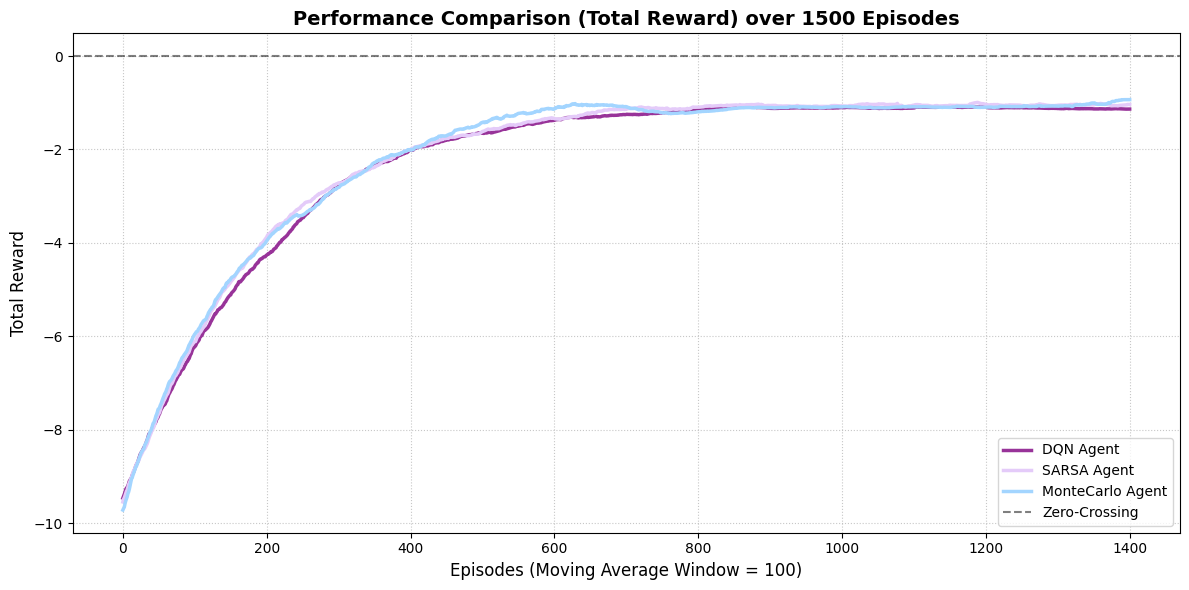

In [68]:
plt.figure(figsize=(12, 6))
window = 100 
for algo in ALGOS:
    plt.plot(moving_average(data[algo]["rewards"], window), 
             label=f'{algo} Agent', color=COLORS[algo], linewidth=2.5)

plt.title('Performance Comparison (Total Reward) over 1500 Episodes', fontsize=14, fontweight='bold')
plt.xlabel(f'Episodes (Moving Average Window = {window})', fontsize=12)
plt.ylabel('Total Reward', fontsize=12)
plt.axhline(y=0, color='black', linestyle='--', alpha=0.5, label='Zero-Crossing')
plt.legend()
plt.grid(True, linestyle=':', alpha=0.7)
plt.tight_layout()
plt.show()

Computation time comparison:

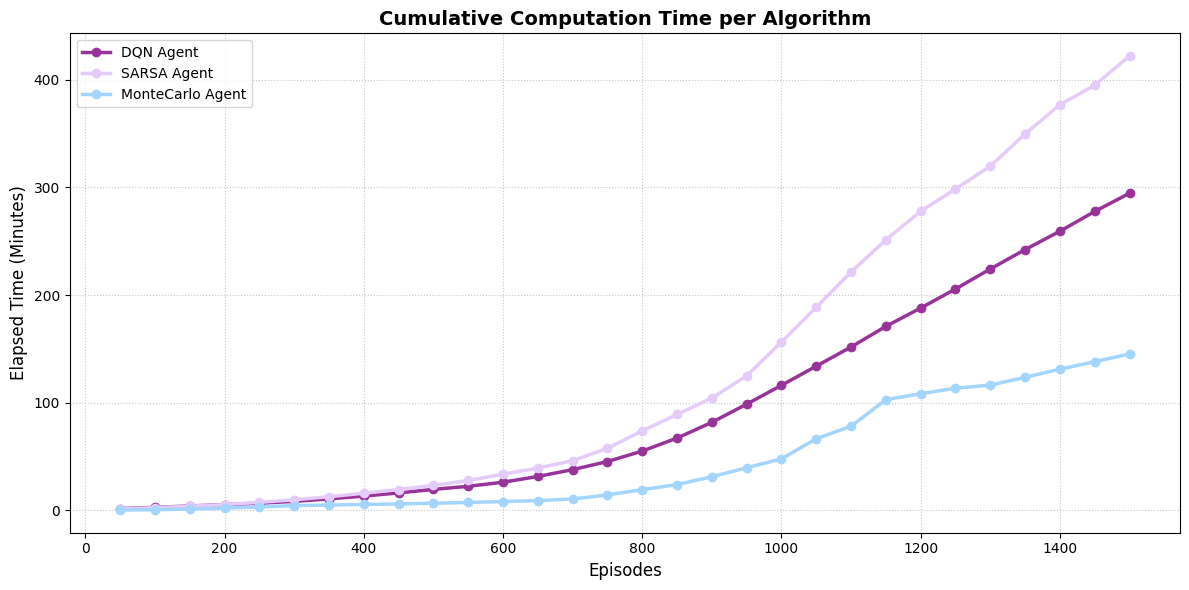

In [71]:
plt.figure(figsize=(12, 6))
episodes_logs = np.arange(LOG_INTERVAL, MAX_EPISODES + LOG_INTERVAL, LOG_INTERVAL)

for algo in ALGOS:
    plt.plot(episodes_logs, data[algo]["times"], 
             label=f'{algo} Agent', color=COLORS[algo], linewidth=2.5, marker='o')

plt.title('Cumulative Computation Time per Algorithm', fontsize=14, fontweight='bold')
plt.xlabel('Episodes', fontsize=12)
plt.ylabel('Elapsed Time (Minutes)', fontsize=12)
plt.legend()
plt.grid(True, linestyle=':', alpha=0.7)
plt.tight_layout()
plt.show()

Final action distribution comparison:

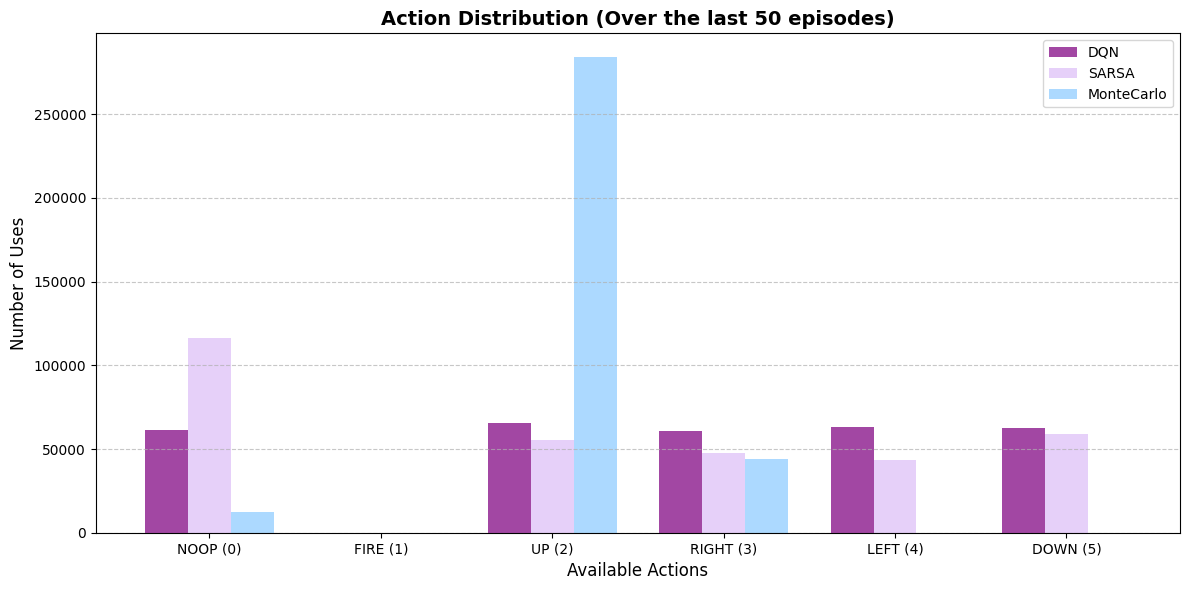

In [78]:
plt.figure(figsize=(12, 6))
bar_width = 0.25
indices = np.arange(len(ACTIONS_LABELS))

for i, algo in enumerate(ALGOS):
    # Extracting of the last round of episodes, the last set of data
    last_log = data[algo]["actions_history"][-1]["action_counts"]
    # JSON saves dictionary keys as strings ("0", "1"...), so we cast act_idx to str
    counts = [last_log.get(str(act_idx), 0) for act_idx in range(6)]
    
    plt.bar(indices + i * bar_width, counts, bar_width, 
            label=algo, color=COLORS[algo], alpha=0.9)

plt.title('Action Distribution (Over the last 50 episodes)', fontsize=14, fontweight='bold')
plt.xlabel('Available Actions', fontsize=12)
plt.ylabel('Number of Uses', fontsize=12)
plt.xticks(indices + bar_width, ACTIONS_LABELS)
plt.legend()
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

Evolution of the 6 actions for each algorithm:

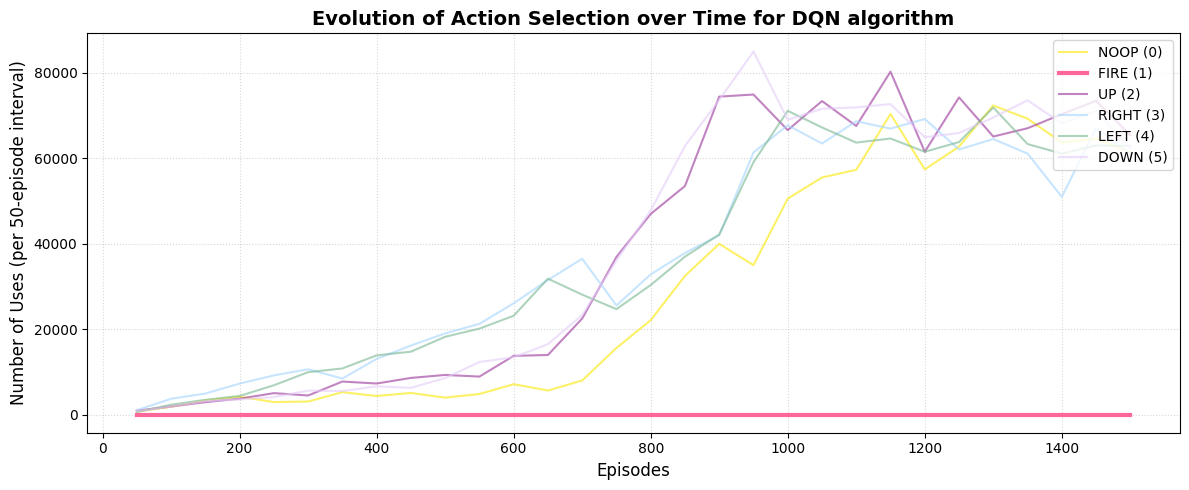

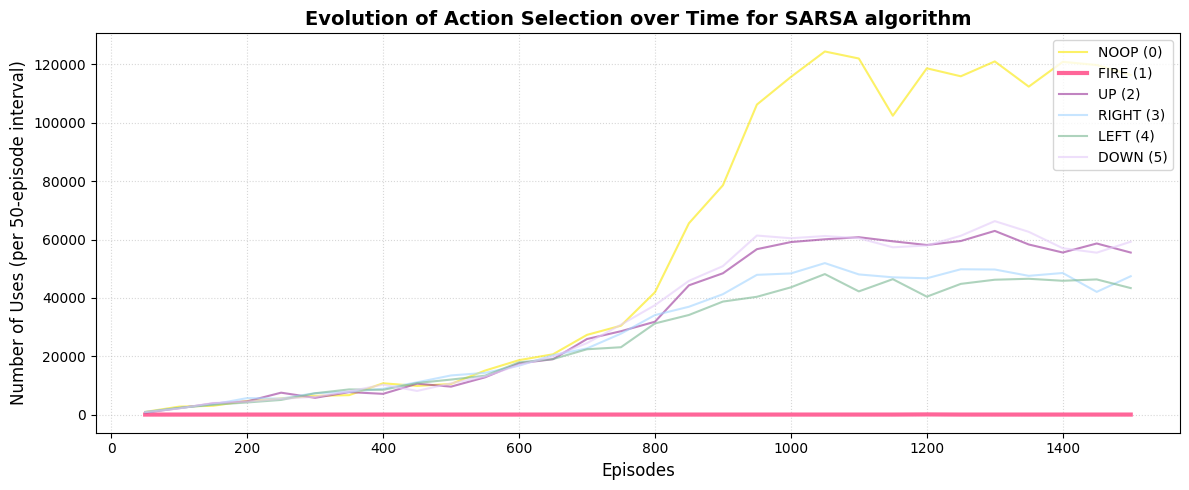

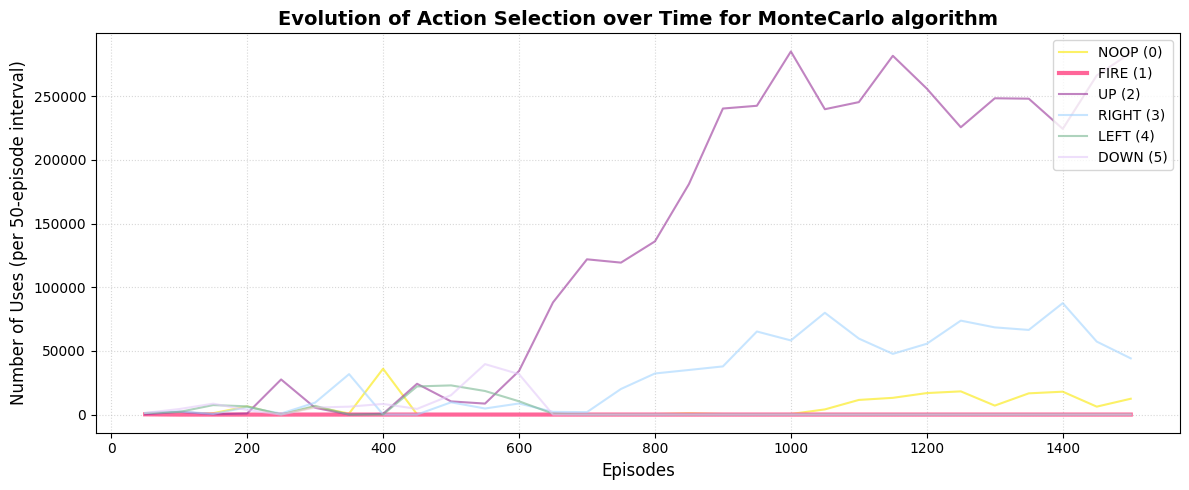

In [ ]:
for algo in ALGOS:
    plt.figure(figsize=(12, 5))
    history = data[algo]["actions_history"]
    
    # Extracting data for each action
    for act_idx in range(6):
        counts = [log["action_counts"].get(str(act_idx), 0) for log in history]
        # Highlighting the FIRE button 
        lw = 3 if act_idx == 1 else 1.5
        alpha = 1.0 if act_idx == 1 else 0.6
        
        plt.plot(episodes_logs, counts, label=ACTIONS_LABELS[act_idx], 
                 color=ACTION_COLORS[act_idx], linewidth=lw, alpha=alpha)

    plt.title(f'Evolution of Action Selection over Time for {algo} algorithm', fontsize=14, fontweight='bold')
    plt.xlabel('Episodes', fontsize=12)
    plt.ylabel('Number of Uses (per 50-episode interval)', fontsize=12)
    plt.legend(loc='upper right')
    plt.grid(True, linestyle=':', alpha=0.5)
    plt.tight_layout()
    plt.show()

# 6. Live Diagnostics and Hypothesis Elimination

## 6.1. Live Diagnostics 

In [10]:
test_agent = DeepMCAgent(state_size=128, action_size=6)

test_agent.q_network.load_state_dict(torch.load("MonteCarlo_basicmath_1500.pth"))
test_agent.q_network.eval()

# Using 'human' to see the game window
test_env = gym.make('ALE/BasicMath-v5', obs_type="ram", render_mode="human")
test_env = ActionPenaltyWrapper(test_env, fire_penalty=-0.1) 

test_agent.epsilon = 0.0 

state, _ = test_env.reset()
done, truncated = False, False
step_count = 0
max_test_steps = 250 # Strict time limit to prevent infinite waiting

total_test_reward = 0

while not done and not truncated and step_count < max_test_steps:
    action = test_agent.act(state)
    state, reward, done, truncated, _ = test_env.step(action)
    total_test_reward += reward
    step_count += 1

test_env.close()

print(f"Test finished after {step_count} steps.")
print(f"Total Reward accumulated: {total_test_reward:.2f}")
if step_count >= max_test_steps:
    print("Result: Episode was forcibly truncated due to time limit (Agent paralysis).")

Test finished after 250 steps.
Total Reward accumulated: 0.00
Result: Episode was forcibly truncated due to time limit (Agent paralysis).


## 6.2. Penalty Hypothesis elimination

In [11]:
TOTAL_EPISODES = 800
SAVE_FILE = "penalty_hyp.json"
PENALTIES = [0.0, -0.01]
algo_name = 'MonteCarlo'
COLORS = {-0.01: '#983399',  0.00: '#E4CBF9'}

all_results = {
    penalty: {
        "rewards": [], 
        "times": [], 
        "actions_history": [] 
    } for penalty in PENALTIES
}

for CHOSEN_PENALTY in PENALTIES:
    print(f"Starting training with penalty {CHOSEN_PENALTY}")
   
    env= ActionPenaltyWrapper(gym.make('ALE/BasicMath-v5', obs_type="ram"), fire_penalty=CHOSEN_PENALTY)
    agent = DeepMCAgent(state_size=128, action_size=6)
    start_time = time.time()
    
    for e in range(TOTAL_EPISODES):
        state, _ = env.reset()
        total_reward = 0
        done = False
        truncated = False
        
        while not done and not truncated:
            action = agent.act(state)
            next_state, reward, done, truncated, _ = env.step(action)
            agent.step(state, action, reward, next_state, done)
            state = next_state
            total_reward += reward
            
        agent.update_epsilon()
        all_results[CHOSEN_PENALTY]["rewards"].append(float(total_reward))
        
        if (e + 1) % 50 == 0:
            avg_reward = np.mean(all_results[CHOSEN_PENALTY]["rewards"][-50:])
            elapsed_minutes = (time.time() - start_time) / 60
            all_results[CHOSEN_PENALTY]["times"].append(elapsed_minutes)

            current_actions = {int(k): int(v) for k, v in agent.greedy_actions_count.items()}
            all_results[CHOSEN_PENALTY]["actions_history"].append({
                "episode": e + 1,
                "action_counts": current_actions
            })
            
            agent.greedy_actions_count = {i: 0 for i in range(6)}
            
            with open(SAVE_FILE, 'w') as f:
                json.dump(all_results, f)
                
            print(f"[{CHOSEN_PENALTY}] Ep: {e+1}/{TOTAL_EPISODES} | Eps: {agent.epsilon:.3f} | Avg Reward: {avg_reward:.2f} | Time: {elapsed_minutes:.1f} min")
            

    torch.save(agent.q_network.state_dict(), f"{CHOSEN_PENALTY}_penalty_hyp_800.pth")
    env.close()


Starting training with penalty 0.0
[0.0] Ep: 50/800 | Eps: 0.778 | Avg Reward: 0.10 | Time: 0.4 min
[0.0] Ep: 100/800 | Eps: 0.606 | Avg Reward: 0.12 | Time: 0.8 min
[0.0] Ep: 150/800 | Eps: 0.471 | Avg Reward: 0.16 | Time: 1.2 min
[0.0] Ep: 200/800 | Eps: 0.367 | Avg Reward: 0.16 | Time: 1.6 min
[0.0] Ep: 250/800 | Eps: 0.286 | Avg Reward: 0.32 | Time: 2.1 min
[0.0] Ep: 300/800 | Eps: 0.222 | Avg Reward: 0.40 | Time: 2.7 min
[0.0] Ep: 350/800 | Eps: 0.173 | Avg Reward: 0.20 | Time: 3.2 min
[0.0] Ep: 400/800 | Eps: 0.135 | Avg Reward: 0.22 | Time: 3.8 min
[0.0] Ep: 450/800 | Eps: 0.105 | Avg Reward: 0.32 | Time: 4.5 min
[0.0] Ep: 500/800 | Eps: 0.082 | Avg Reward: 0.10 | Time: 5.1 min
[0.0] Ep: 550/800 | Eps: 0.063 | Avg Reward: 0.22 | Time: 6.1 min
[0.0] Ep: 600/800 | Eps: 0.049 | Avg Reward: 0.18 | Time: 7.0 min
[0.0] Ep: 650/800 | Eps: 0.038 | Avg Reward: 0.10 | Time: 7.9 min
[0.0] Ep: 700/800 | Eps: 0.030 | Avg Reward: 0.26 | Time: 9.6 min
[0.0] Ep: 750/800 | Eps: 0.023 | Avg Rewar

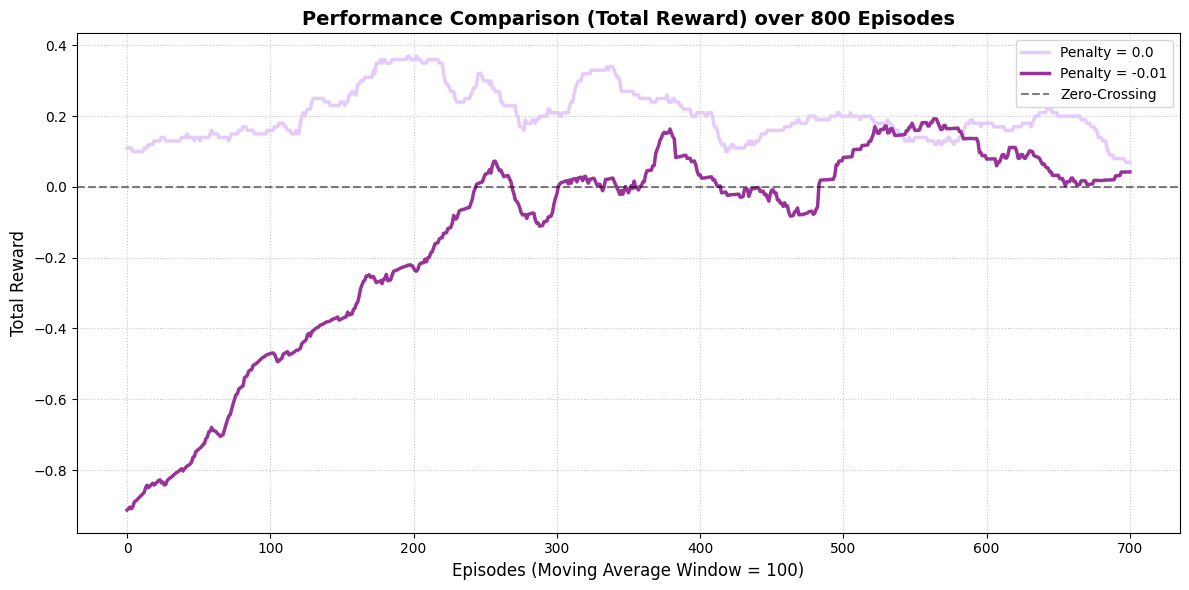

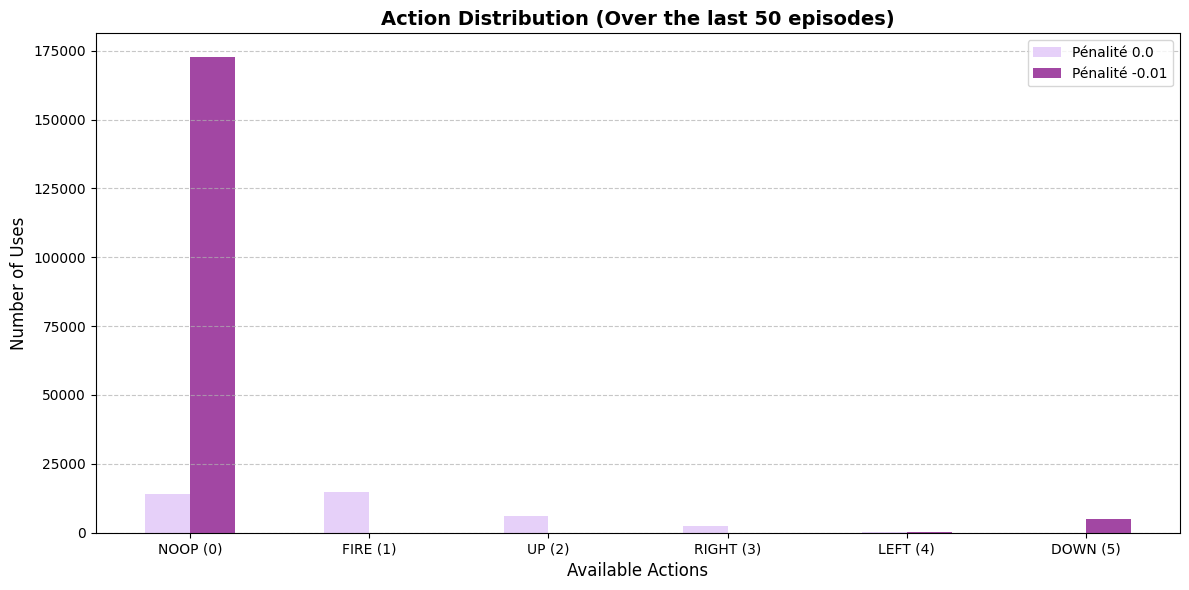

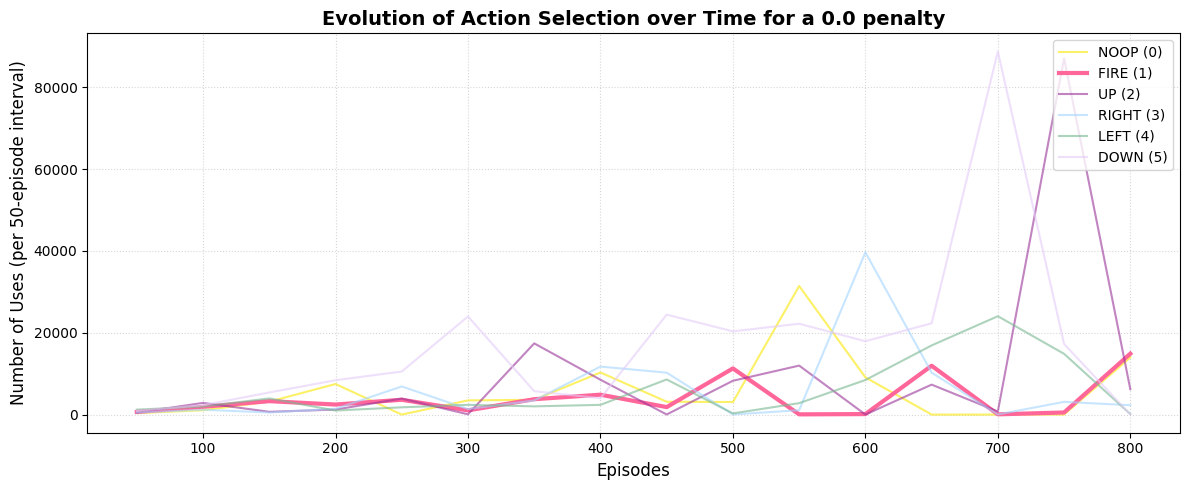

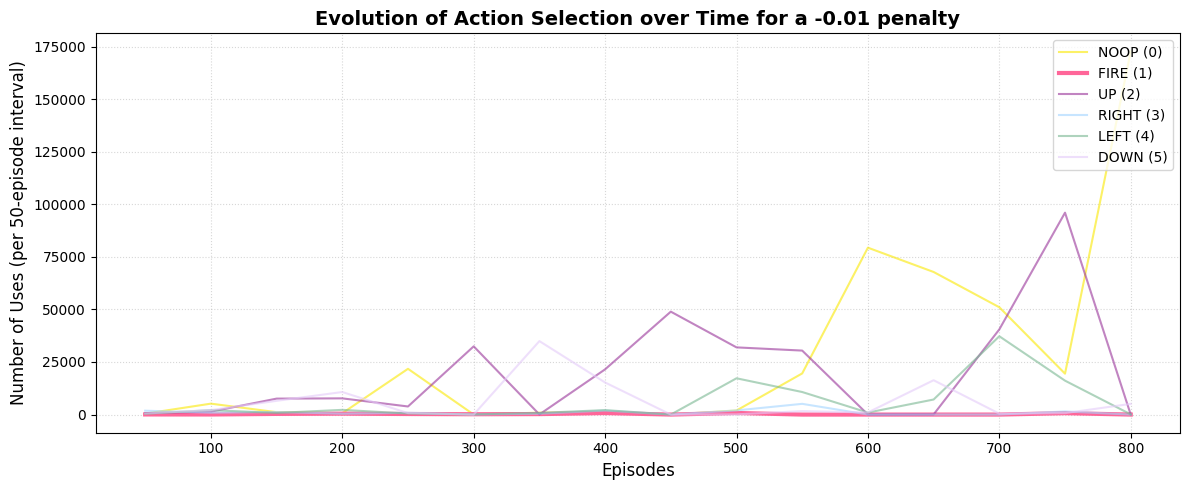

In [18]:
SAVE_FILE = "penalty_hyp.json"
PENALTIES = [0.0, -0.01]
algo = 'MonteCarlo'

COLORS = {-0.01: '#983399', 0.0: '#E4CBF9' }

MAX_EPISODES = 800
LOG_INTERVAL = 50
MAX_LOGS = MAX_EPISODES // LOG_INTERVAL  # = 16 points

with open(SAVE_FILE, 'r') as f:
    data = json.load(f)

ACTIONS_LABELS = ['NOOP (0)', 'FIRE (1)', 'UP (2)', 'RIGHT (3)', 'LEFT (4)', 'DOWN (5)']
ACTION_COLORS = ['#FAE801', '#FF6699', '#983399', '#A3D5FF', '#79B791', '#E4CBF9']

def moving_average(data, window_size=100):
    return np.convolve(data, np.ones(window_size)/window_size, mode='valid')


# Graph 1 - Reward

plt.figure(figsize=(12, 6))
window = 100 
for penalty in PENALTIES:
    p_key = str(penalty) 
    plt.plot(moving_average(data[p_key]["rewards"], window), 
             label=f'Penalty = {penalty}', color=COLORS[penalty], linewidth=2.5)

plt.title('Performance Comparison (Total Reward) over 800 Episodes', fontsize=14, fontweight='bold')
plt.xlabel(f'Episodes (Moving Average Window = {window})', fontsize=12)
plt.ylabel('Total Reward', fontsize=12)
plt.axhline(y=0, color='black', linestyle='--', alpha=0.5, label='Zero-Crossing')
plt.legend()
plt.grid(True, linestyle=':', alpha=0.7)
plt.tight_layout()
plt.show()

# Graph 2 - Action disribution

plt.figure(figsize=(12, 6))
bar_width = 0.25
indices = np.arange(len(ACTIONS_LABELS))

for i, penalty in enumerate(PENALTIES):
    p_key = str(penalty) 
    last_log = data[p_key]["actions_history"][-1]["action_counts"]
    counts = [last_log.get(str(act_idx), 0) for act_idx in range(6)]
    plt.bar(indices + i * bar_width, counts, bar_width, 
            label=f'Pénalité {penalty}', color=COLORS[penalty], alpha=0.9)

plt.title('Action Distribution (Over the last 50 episodes)', fontsize=14, fontweight='bold')
plt.xlabel('Available Actions', fontsize=12)
plt.ylabel('Number of Uses', fontsize=12)
plt.xticks(indices + bar_width / 2, ACTIONS_LABELS) # Text centering
plt.legend()
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

# Graph 3 & 4 - Action per penalty

episodes_logs = np.arange(LOG_INTERVAL, MAX_EPISODES + LOG_INTERVAL, LOG_INTERVAL)

for penalty in PENALTIES:
    p_key = str(penalty)
    plt.figure(figsize=(12, 5))
    history = data[p_key]["actions_history"]
    
    for act_idx in range(6):
        counts = [log["action_counts"].get(str(act_idx), 0) for log in history]
        # On met en valeur le bouton FIRE (rouge, plus épais)
        lw = 3 if act_idx == 1 else 1.5
        alpha = 1.0 if act_idx == 1 else 0.6
        
        plt.plot(episodes_logs, counts, label=ACTIONS_LABELS[act_idx], 
                 color=ACTION_COLORS[act_idx], linewidth=lw, alpha=alpha)

    plt.title(f'Evolution of Action Selection over Time for a {penalty} penalty', fontsize=14, fontweight='bold')
    plt.xlabel('Episodes', fontsize=12)
    plt.ylabel('Number of Uses (per 50-episode interval)', fontsize=12)
    plt.legend(loc='upper right')
    plt.grid(True, linestyle=':', alpha=0.5)
    plt.tight_layout()
    plt.show()

## 6.3. Absolute "Fear of FIRE" Hypothesis

In [15]:
TOTAL_EPISODES = 1000
MAX_STEPS_BEFORE_FIRE = 250 
PENALTY = -0.01  
SAVE_JSON = "forced-MC_0.01.json"
SAVE_PTH = "forced-MC_0.01.pth"

data_to_save = {
    "Forced_MonteCarlo": {
        "rewards": [],
        "actions_history": []
    }
}

env = ActionPenaltyWrapper(gym.make('ALE/BasicMath-v5', obs_type="ram"), fire_penalty=PENALTY)
agent = DeepMCAgent(state_size=128, action_size=6)

current_50_actions = {i: 0 for i in range(6)}

for e in range(TOTAL_EPISODES):
    state, _ = env.reset()
    total_reward = 0
    done = False
    truncated = False
    step_count = 0  
    
    while not done and not truncated:
        step_count += 1
        if step_count == MAX_STEPS_BEFORE_FIRE:
            action = 1  # Action 1 = FIRE
        else:
            action = agent.act(state) 
            
        current_50_actions[int(action)] += 1
        
        next_state, reward, done, truncated, _ = env.step(action)
        
        if step_count >= MAX_STEPS_BEFORE_FIRE:
            done = True 
            
        agent.step(state, action, reward, next_state, done)
        
        state = next_state
        total_reward += reward
        
    agent.update_epsilon()
    data_to_save["Forced_MonteCarlo"]["rewards"].append(float(total_reward))
    
    if (e + 1) % 50 == 0:
        avg_reward = np.mean(data_to_save["Forced_MonteCarlo"]["rewards"][-50:])
        
        data_to_save["Forced_MonteCarlo"]["actions_history"].append({
            "episode": e + 1,
            "action_counts": dict(current_50_actions)
        })
        current_50_actions = {i: 0 for i in range(6)}
        
        with open(SAVE_JSON, 'w') as f:
            json.dump(data_to_save, f)
            
        print(f"Ep: {e+1}/{TOTAL_EPISODES} | Eps: {agent.epsilon:.3f} | Avg Reward: {avg_reward:.2f} | Time: {elapsed_minutes:.1f} min")
       

torch.save(agent.q_network.state_dict(), SAVE_PTH)

env.close()



Ep: 50/1000 | Eps: 0.778 | Avg Reward: -0.33 | Time: 13.5 min
Ep: 100/1000 | Eps: 0.606 | Avg Reward: -0.24 | Time: 13.5 min
Ep: 150/1000 | Eps: 0.471 | Avg Reward: -0.18 | Time: 13.5 min
Ep: 200/1000 | Eps: 0.367 | Avg Reward: -0.15 | Time: 13.5 min
Ep: 250/1000 | Eps: 0.286 | Avg Reward: -0.06 | Time: 13.5 min
Ep: 300/1000 | Eps: 0.222 | Avg Reward: -0.00 | Time: 13.5 min
Ep: 350/1000 | Eps: 0.173 | Avg Reward: -0.06 | Time: 13.5 min
Ep: 400/1000 | Eps: 0.135 | Avg Reward: -0.05 | Time: 13.5 min
Ep: 450/1000 | Eps: 0.105 | Avg Reward: -0.06 | Time: 13.5 min
Ep: 500/1000 | Eps: 0.082 | Avg Reward: -0.05 | Time: 13.5 min
Ep: 550/1000 | Eps: 0.063 | Avg Reward: -0.04 | Time: 13.5 min
Ep: 600/1000 | Eps: 0.049 | Avg Reward: -0.03 | Time: 13.5 min
Ep: 650/1000 | Eps: 0.038 | Avg Reward: -0.03 | Time: 13.5 min
Ep: 700/1000 | Eps: 0.030 | Avg Reward: -0.03 | Time: 13.5 min
Ep: 750/1000 | Eps: 0.023 | Avg Reward: -0.02 | Time: 13.5 min
Ep: 800/1000 | Eps: 0.018 | Avg Reward: -0.03 | Time: 13

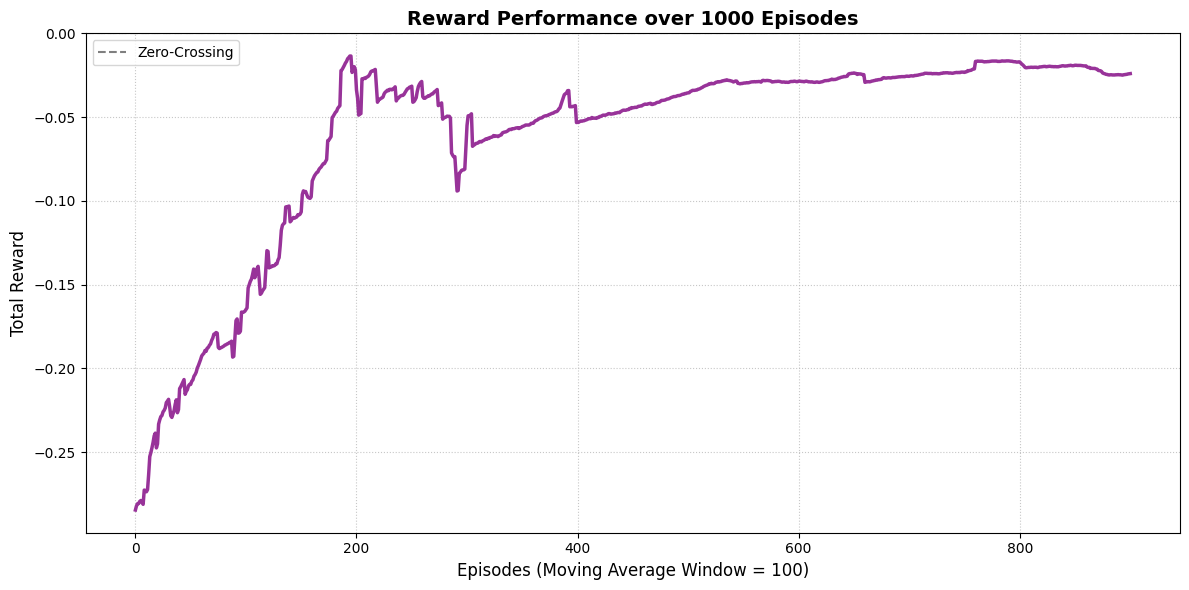

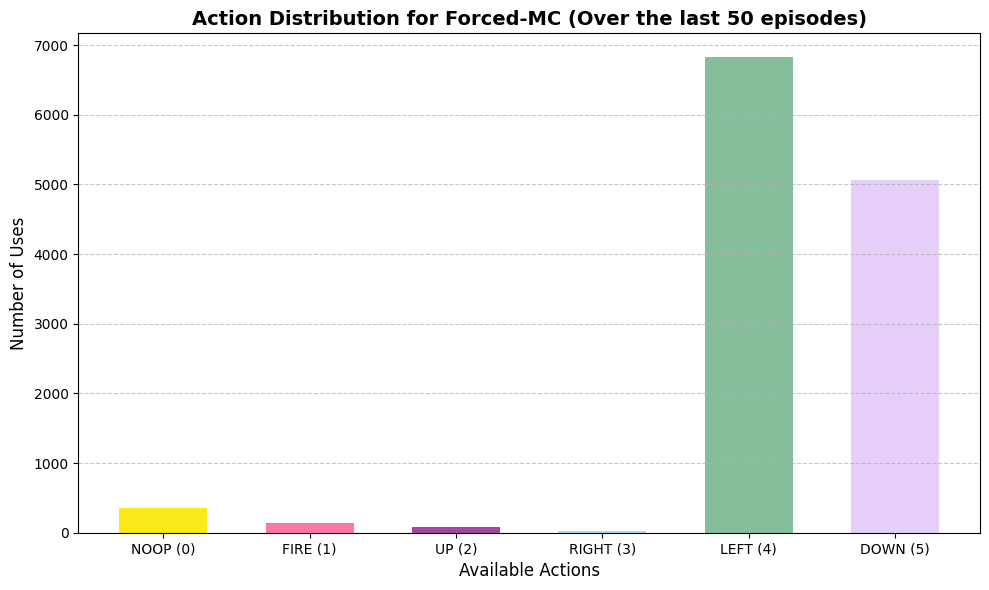

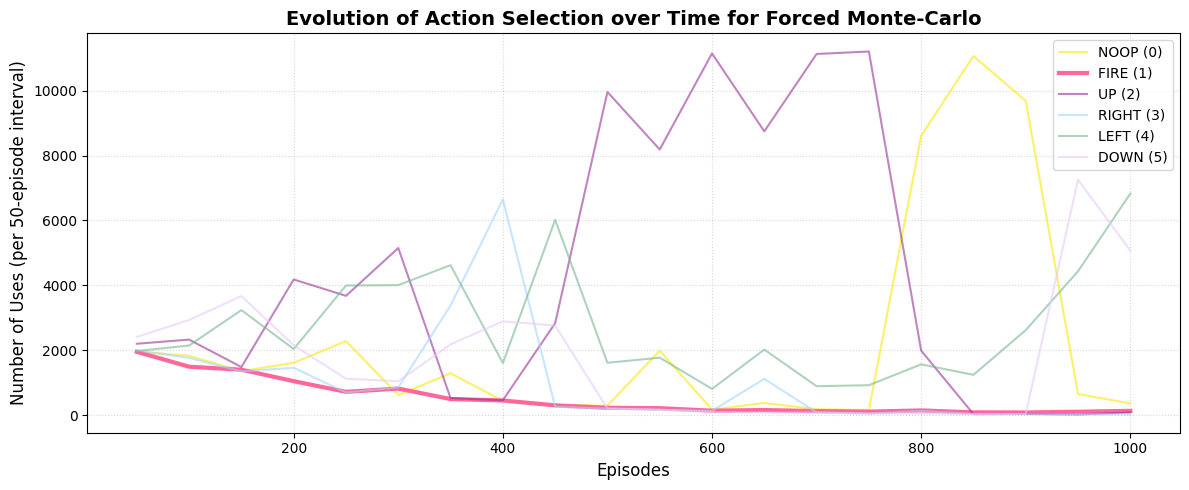

In [29]:
SAVE_FILE = "forced-MC_0.01.json"
MAX_EPISODES = 1000
LOG_INTERVAL = 50
MAX_LOGS = MAX_EPISODES // LOG_INTERVAL # = 20

with open(SAVE_FILE, 'r') as f:
    data = json.load(f)

data_to_save = {
    "Forced_MonteCarlo": {
        "rewards": [],
        "actions_history": []
    }
}

# Graph 1 - Reward

plt.figure(figsize=(12, 6))
window = 100 
plt.plot(moving_average(data["Forced_MonteCarlo"]["rewards"], window), color= '#983399', linewidth=2.5)

plt.title('Reward Performance over 1000 Episodes', fontsize=14, fontweight='bold')
plt.xlabel(f'Episodes (Moving Average Window = {window})', fontsize=12)
plt.ylabel('Total Reward', fontsize=12)
plt.axhline(y=0, color='black', linestyle='--', alpha=0.5, label='Zero-Crossing')
plt.legend()
plt.grid(True, linestyle=':', alpha=0.7)
plt.tight_layout()
plt.show()

# Graph 2

ACTIONS_LABELS = ['NOOP (0)', 'FIRE (1)', 'UP (2)', 'RIGHT (3)', 'LEFT (4)', 'DOWN (5)']
colors = ['#FAE801', '#FF6699', '#983399', '#A3D5FF', '#79B791', '#E4CBF9']

plt.figure(figsize=(10, 6))
indices = np.arange(len(ACTIONS_LABELS))

last_log = data["Forced_MonteCarlo"]["actions_history"][-1]["action_counts"]
counts = [last_log.get(str(act_idx), 0) for act_idx in range(6)]

plt.bar(indices, counts, width=0.6, label="Forced Monte Carlo Agent", color=colors, alpha=0.9)
plt.title('Action Distribution for Forced-MC (Over the last 50 episodes)', fontsize=14, fontweight='bold')
plt.xlabel('Available Actions', fontsize=12)
plt.ylabel('Number of Uses', fontsize=12)
plt.xticks(indices, ACTIONS_LABELS)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

# Graph 3

plt.figure(figsize=(12, 5))
history = data["Forced_MonteCarlo"]["actions_history"]
episodes_logs = [i * 50 for i in range(1, len(history) + 1)]

for act_idx in range(6):
    counts = [log["action_counts"].get(str(act_idx), 0) for log in history]
    
    lw = 3 if act_idx == 1 else 1.5
    alpha = 1.0 if act_idx == 1 else 0.6
    
    plt.plot(episodes_logs, counts, label=ACTIONS_LABELS[act_idx], 
             color=ACTION_COLORS[act_idx], linewidth=lw, alpha=alpha)

plt.title('Evolution of Action Selection over Time for Forced Monte-Carlo', fontsize=14, fontweight='bold')
plt.xlabel('Episodes', fontsize=12)
plt.ylabel("Number of Uses (per 50-episode interval)", fontsize=12)
plt.legend(loc='upper right')
plt.grid(True, linestyle=':', alpha=0.5)
plt.tight_layout()
plt.show()

# The end